<a href="https://colab.research.google.com/github/shehzadtm/KhuramFiles/blob/main/SPYTrade_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Load SPY ETF Data

First, I will mount Google Drive to access your file and load the SPY ETF data using pandas.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install yfinance

!pip install pandas_ta

# Install Noto Color Emoji font for better emoji rendering in plots
!apt-get install -y fonts-noto-color-emoji
# Clear and rebuild matplotlib font cache
!rm -rf /root/.cache/matplotlib
import matplotlib.font_manager
!pip install xlsxwriter
# matplotlib.font_manager._rebuild()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-noto-color-emoji
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 10.0 MB of archives.
After this operation, 11.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 fonts-noto-color-emoji all 2.047-0ubuntu0.22.04.1 [10.0 MB]
Fetched 10.0 MB in 0s (41.8 MB/s)
Selecting previously unselected package fonts-noto-color-emoji.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-noto-color-emoji_2.047-0ubuntu0.22.04.1_all.deb ...
Unpacking fonts-noto-color-emoji (2.047-0ubuntu0.22.04.1) ...
Setting up fonts-noto-color-emoji (2.047-0ubuntu0.22.04.1) ...
Processing triggers for fontconfig (

In [ ]:
import pandas as pd
import yfinance as yf
import pandas_ta as ta

# 1. Define portfolio tickers directly from your snapshot
portfolio_tickers = [
    "ACHR", "AVGO", "BRK-B", "BSX", "CERT", "CMPS", "CODX",
    "CRM", "ENLV", "IBKR", "JOBY", "LUNG", "MDT", "META",
    "MSFT", "NASA", "NFLX", "SCHW"
]

def analyze_portfolio_metrics(tickers, period="6mo"): # Corrected '6m' to '6mo'
    analysis_results = []

    for ticker in tickers:
        try:
            # Download historical data
            df = yf.download(ticker, period=period, progress=False)
            if df.empty or len(df) < 20:
                continue

            # Flatten column multi-index if returned by yfinance
            if isinstance(df.columns, pd.MultiIndex):
                df.columns = df.columns.get_level_values(0)

            # Calculate Core Technical Data via pandas_ta
            df['RSI'] = ta.rsi(df['Close'], length=14)

            # Calculate MACD
            macd_df = ta.macd(df['Close'], fast=12, slow=26, signal=9)
            df['MACD'] = macd_df.iloc[:, 0]
            df['MACD_Signal'] = macd_df.iloc[:, 1]
            df['MACD_Hist'] = macd_df.iloc[:, 2]

            # Calculate Moving Averages
            df['SMA_20'] = ta.sma(df['Close'], length=20)
            df['SMA_50'] = ta.sma(df['Close'], length=50)
            df['SMA_200'] = ta.sma(df['Close'], length=200)

            # Calculate Money Flow Index (MFI)
            df['MFI'] = ta.mfi(df['High'], df['Low'], df['Close'], df['Volume'], length=14)

            # Get latest values
            latest = df.iloc[-1]
            prev = df.iloc[-2]

            # Trend evaluations
            price_vs_sma50 = "Above" if latest['Close'] > latest['SMA_50'] else "Below"
            macd_cross = "Bullish Crossover" if (latest['MACD'] > latest['MACD_Signal'] and prev['MACD'] <= prev['MACD_Signal']) \
                         else "Bearish Crossover" if (latest['MACD'] < latest['MACD_Signal'] and prev['MACD'] >= prev['MACD_Signal']) \
                         else "No Cross"

            # Calculate distance from 50-day moving average (Volatility / Breakaway proxy)
            pct_dist_sma50 = ((latest['Close'] - latest['SMA_50']) / latest['SMA_50']) * 100

            analysis_results.append({
                "Ticker": ticker,
                "Last Price": round(latest['Close'], 2),
                "RSI (14)": round(latest['RSI'], 2) if not pd.isna(latest['RSI']) else None,
                "MFI (14)": round(latest['MFI'], 2) if not pd.isna(latest['MFI']) else None,
                "MACD Status": macd_cross,
                "Price vs SMA50": price_vs_sma50,
                "Dist from SMA50 (%)": round(pct_dist_sma50, 2) if not pd.isna(pct_dist_sma50) else 0.0
            })

        except Exception as e:
            print(f"Could not process asset {ticker}: {e}")

    return pd.DataFrame(analysis_results)

# Execute the analysis
portfolio_df = analyze_portfolio_metrics(portfolio_tickers)

# Sort by absolute distance from the mean trend to highlight index break-apart candidates
portfolio_df['Abs_Dist'] = portfolio_df['Dist from SMA50 (%)'].abs()
portfolio_df = portfolio_df.sort_values(by='Abs_Dist', ascending=False).drop(columns=['Abs_Dist'])

print("\n=== PORTFOLIO TECHNICAL & MONEY FLOW SUMMARY ===")
print(portfolio_df.to_string(index=False))

/tmp/ipykernel_2561/3663368883.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period=period, progress=False)
/tmp/ipykernel_2561/3663368883.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period=period, progress=False)
/tmp/ipykernel_2561/3663368883.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period=period, progress=False)
/tmp/ipykernel_2561/3663368883.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period=period, progress=False)
/tmp/ipykernel_2561/3663368883.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period=period, progress=False)
/tmp/ipykernel_2561/3663368883.py:18: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.down


=== PORTFOLIO TECHNICAL & MONEY FLOW SUMMARY ===
Ticker  Last Price  RSI (14)  MFI (14)       MACD Status Price vs SMA50  Dist from SMA50 (%)
  CMPS       12.63     59.31     38.91          No Cross          Above                23.25
  ENLV        0.62     34.96     21.52          No Cross          Below               -19.71
   BSX       44.33     25.06     22.88          No Cross          Below               -18.78
  NFLX       72.88     21.42     22.56          No Cross          Below               -17.78
  IBKR       96.82     71.97     64.69          No Cross          Above                15.37
   CRM      150.12     29.97      5.19          No Cross          Below               -15.32
  MSFT      367.34     30.96      6.04          No Cross          Below               -10.91
  NASA       29.75     40.08     23.48 Bearish Crossover          Below                -9.66
  ACHR        5.43     43.17     26.19          No Cross          Below                -9.08
  META      563.85  

### Centralized Data Loading

To ensure efficiency and avoid redundant downloads, all necessary data—the SPY ETF constituent list, SPY historical data for performance comparison, and individual stock historical data—will be loaded in this section. This data will then be accessible globally throughout the notebook for subsequent analysis.

In [ ]:
import pandas as pd
import yfinance as yf
import pandas_ta as ta
import numpy as np

# Define the path to your Excel file
file_path = '/content/drive/MyDrive/StockAnalysis/SPY_ETF-06-01-2026.xlsx'

# Load the SPY ETF data
try:
    spy_df = pd.read_excel(file_path)
    print("SPY ETF constituents loaded successfully!")
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please ensure the path is correct and your Drive is mounted.")
    spy_df = pd.DataFrame() # Create empty DataFrame to avoid errors
except Exception as e:
    print(f"An error occurred while loading the SPY ETF file: {e}")

# Helper function to standardize DataFrame columns from yfinance
def standardize_yfinance_df_columns(df):
    if isinstance(df.columns, pd.MultiIndex):
        new_columns = []
        for col_pair in df.columns:
            if 'Adj Close' in col_pair:
                new_columns.append('Adj Close')
            elif 'Close' in col_pair:
                new_columns.append('Close')
            elif 'Volume' in col_pair:
                new_columns.append('Volume')
            elif 'Open' in col_pair:
                new_columns.append('Open')
            elif 'High' in col_pair:
                new_columns.append('High')
            elif 'Low' in col_pair:
                new_columns.append('Low')
            else:
                new_columns.append('_'.join(filter(None, col_pair)))
        df.columns = new_columns

    if 'Close' in df.columns and 'Adj Close' not in df.columns:
        df['Adj Close'] = df['Close']
    elif 'Adj Close' in df.columns and 'Close' not in df.columns:
        df['Close'] = df['Adj Close']

    if 'volume' in df.columns:
        df.rename(columns={'volume': 'Volume'}, inplace=True)

    return df

# Define a function to download data with error handling
def download_stock_data(symbols, start_date, end_date):
    data = {} # Dictionary to store DataFrames for each stock
    failed_downloads = []

    print("Downloading data for individual stocks...")
    for symbol in symbols:
        try:
            df = yf.download(symbol, start=start_date, end=end_date, progress=False)
            if not df.empty:
                data[symbol] = df
            else:
                failed_downloads.append(symbol)
        except Exception as e:
            print(f"Error downloading data for {symbol}: {e}")
            failed_downloads.append(symbol)

    if failed_downloads:
        print(f"\nFailed to download data for the following symbols: {', '.join(failed_downloads)}")
    return data

# Define the date range for historical data (e.g., last 5 years)
end_date = pd.to_datetime('today')
start_date = end_date - pd.DateOffset(years=5)

# Download SPY ETF historical data for performance comparison
print("Downloading SPY ETF historical data for performance comparison...")
spy_ticker = 'SPY'
spy_historical_df_raw = yf.download(spy_ticker, start=start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'), progress=False)
spy_historical_df = standardize_yfinance_df_columns(spy_historical_df_raw.copy()) # Apply standardization

if spy_historical_df.empty:
    print(f"Error: Could not download historical data for {spy_ticker}.")
else:
    print(f"Successfully downloaded SPY data.")
    spy_historical_df['SPY_Daily_Return'] = spy_historical_df['Adj Close'].pct_change()
    spy_historical_df['SPY_Cumulative_Return'] = (1 + spy_historical_df['SPY_Daily_Return']).cumprod() - 1

# Extract stock symbols from spy_df and download individual stock data
if not spy_df.empty:
    stock_symbols = spy_df['Identifier'].tolist()
    print(f"Extracted {len(stock_symbols)} stock symbols. Downloading individual stock data...")
    all_stocks_data = download_stock_data(stock_symbols, start_date.strftime('%Y-%m-%d'), end_date.strftime('%Y-%m-%d'))
    print(f"\nSuccessfully downloaded data for {len(all_stocks_data)} out of {len(stock_symbols)} stocks.")
else:
    print("Error: spy_df is empty. Cannot extract stock symbols to download individual stock data.")
    all_stocks_data = {}

SPY ETF constituents loaded successfully!
Successfully downloaded SPY data.
Extracted 505 stock symbols. Downloading individual stock data...


/tmp/ipykernel_2561/1884837719.py:78: FutureWarning: YF.download() has changed argument auto_adjust default to True
  spy_historical_df_raw = yf.download(spy_ticker, start=start_date.strftime('%Y-%m-%d'), end=end_date.strftime('%Y-%m-%d'), progress=False)
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/tmp/ipykernel_2561/1884837719.py:58: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, start=start_date, end=end_date, progress=False)
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/history.py:204: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  dt_now = pd.Timestamp.utcnow()
/tmp/ipykernel_2561/1884837719.py:58: FutureWarning: YF.download() has changed argument auto_ad


Failed to download data for the following symbols: BRK.B, -, BF.B, 2602335D

Successfully downloaded data for 501 out of 505 stocks.


In [ ]:
import pandas as pd
import pandas_ta as ta # Import pandas_ta
import numpy as np # Might be needed for NaN handling or other numerical ops
import json # To store normalized indicators as string in Excel
import matplotlib.pyplot as plt
import matplotlib.font_manager
from math import pi
import io

!pip install xlsxwriter # Install xlsxwriter if not already installed
from xlsxwriter.utility import xl_rowcol_to_cell

# --- BEGIN: Function to get performance metrics ---
def get_performance_metrics(df_stock, spy_df_historical, recent_lookback_days=7, relative_perf_lookback_days=90):
    recent_price_change_pct = np.nan
    relative_performance = np.nan

    if df_stock.empty or 'Adj Close' not in df_stock.columns:
        return recent_price_change_pct, relative_performance

    # Recent Price Change (e.g., last 7 days)
    if len(df_stock) >= recent_lookback_days:
        recent_data = df_stock.tail(recent_lookback_days)
        start_price = recent_data['Adj Close'].iloc[0]
        end_price = recent_data['Adj Close'].iloc[-1]
        if start_price != 0:
            recent_price_change_pct = ((end_price - start_price) / start_price) * 100

    # Relative Performance to SPY (e.g., last 90 days)
    if len(df_stock) >= relative_perf_lookback_days and not spy_df_historical.empty:
        stock_lookback_df = df_stock.tail(relative_perf_lookback_days).copy()
        spy_aligned_df = spy_df_historical.loc[stock_lookback_df.index.min():stock_lookback_df.index.max()].copy()

        if not spy_aligned_df.empty and 'SPY_Cumulative_Return' in spy_aligned_df.columns:
            stock_perf_start = stock_lookback_df['Adj Close'].iloc[0]
            stock_perf_end = stock_lookback_df['Adj Close'].iloc[-1]
            stock_performance = (stock_perf_end - stock_perf_start) / stock_perf_start

            spy_perf_start = spy_aligned_df['Adj Close'].iloc[0]
            spy_perf_end = spy_aligned_df['Adj Close'].iloc[-1]
            spy_performance = (spy_perf_end - spy_perf_start) / spy_perf_start

            relative_performance = stock_performance - spy_performance

    return recent_price_change_pct, relative_performance
# --- END: Function to get performance metrics ---

# --- BEGIN: Helper function for spider charts ---
def plot_spider_chart_to_bytes(symbol, normalized_indicators, decision, color='blue'):
    if not normalized_indicators:
        return None

    categories = list(normalized_indicators.keys())
    values = list(normalized_indicators.values())

    # Ensure the plot closes the circle
    categories = categories + [categories[0]]
    values = values + [values[0]]

    # Calculate angle for each category
    angles = [n / float(len(categories) - 1) * 2 * pi for n in range(len(categories))]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories[:-1], color='grey', size=8)

    ax.set_yticklabels([]) # Hide radial labels for cleaner look
    ax.set_ylim(0, 1)

    ax.plot(angles, values, linewidth=2, linestyle='solid', label=symbol, color=color)
    ax.fill(angles, values, color, alpha=0.25)

    # Modify title to include the decision
    ax.set_title(f'{symbol} TA Profile ({decision})', size=12, color='black', position=(0.95, 1.1), ha='right')

    # Add green checkmark if decision is a 'Buy' type
    if decision and ("Buy" in decision or "Growth" in decision):
        # Use a font that supports emojis, e.g., Noto Color Emoji
        prop = matplotlib.font_manager.FontProperties(family='Noto Color Emoji', size=15)
        ax.text(0.9, 0.9, '✅', transform=ax.transAxes, # Adjust position within the plot
                fontsize=15, ha='right', va='top', color='green', fontproperties=prop)

    plt.tight_layout()
    img_bytes = io.BytesIO()
    plt.savefig(img_bytes, format='png', bbox_inches='tight')
    plt.close(fig)
    img_bytes.seek(0)
    return img_bytes
# --- END: Helper function for spider charts ---

# --- BEGIN: Combined Function for Technical Analysis Scoring and Normalized Indicators ---
def calculate_technical_metrics(df, ticker_symbol):
    # Ensure the DataFrame has a DatetimeIndex for pandas_ta
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)

    df_copy = df.copy()

    # Calculate Indicators
    df_copy.ta.macd(append=True)
    df_copy.ta.rsi(append=True)

    bb_results = ta.bbands(df_copy['Close'], length=20, std=2)
    if bb_results is not None and not bb_results.empty:
        df_copy = df_copy.join(bb_results)

    df_copy.ta.stoch(append=True)
    df_copy.ta.adx(append=True)
    df_copy.ta.sma(length=50, append=True)

    # Calculate Money Flow Index (MFI)
    df_copy['MFI_14'] = ta.mfi(df_copy['High'], df_copy['Low'], df_copy['Close'], df_copy['Volume'], length=14)

    # Calculate 30-day SMA for Volume (for Relative Volume)
    df_copy['Volume_SMA_30'] = ta.sma(df_copy['Volume'], length=30)

    # After calculations, drop rows that might have NaNs from indicator calculations
    initial_rows = len(df_copy)
    df_copy.dropna(inplace=True)
    if len(df_copy) < initial_rows / 2: # Check if too many rows were dropped
        pass # Suppress this print

    if df_copy.empty:
        return None, None, None, None # Return 4 Nones if df_copy is empty

    last = df_copy.iloc[-1]

    # Initialize ADX and Relative Volume values for return
    adx_value = last.get('ADX_14', 0.0)
    relative_volume_value = 0.0
    if 'Volume_SMA_30' in last.index and pd.notna(last['Volume_SMA_30']) and last['Volume_SMA_30'] != 0:
        relative_volume_value = last['Volume'] / last['Volume_SMA_30']

    # 1. Calculate Technical Score (1-10)
    score = 5 # Neutral start

    if pd.notna(last.get('MACD_12_26_9')) and pd.notna(last.get('MACDs_12_26_9')):
        if last['MACD_12_26_9'] > last['MACDs_12_26_9']: score += 1

    if pd.notna(last.get('RSI_14')):
        if last['RSI_14'] < 30: score += 2 # Oversold (Buy)
        elif last['RSI_14'] > 70: score -= 2 # Overbought (Sell)

    if pd.notna(last.get('SMA_50')):
        if last['Close'] > last['SMA_50']: score += 1

    if 'BBL_20_2.0' in last.index and pd.notna(last['BBL_20_2.0']) and 'BBU_20_2.0' in last.index and pd.notna(last['BBU_20_2.0']):
        if last['Close'] < last['BBL_20_2.0']: score += 1 # Price near lower band (Buy)

    if pd.notna(last.get('STOCHk_14_3_3')) and pd.notna(last.get('STOCHd_14_3_3')):
        if last['STOCHk_14_3_3'] > last['STOCHd_14_3_3']: score += 1

    if pd.notna(adx_value):
        if adx_value > 25: score += 1 # Trend is strong

    if pd.notna(last.get('MFI_14')):
        if last['MFI_14'] < 20: score += 1 # Money Flow is low, potential for reversal
        elif last['MFI_14'] > 80: score -= 1 # Money Flow is high, potential for reversal

    if relative_volume_value > 1.2: # Significantly higher volume
        score += 1
    elif relative_volume_value < 0.8: # Significantly lower volume
        score -= 1

    technical_score = max(1, min(10, score))

    # 2. Calculate Normalized Indicators (0-1)
    normalized_indicators = {}

    if pd.notna(last.get('MACD_12_26_9')) and pd.notna(last.get('MACDs_12_26_9')) and last['Close'] != 0:
        macd_diff = last['MACD_12_26_9'] - last['MACDs_12_26_9']
        relative_macd_diff = macd_diff / last['Close']
        normalized_indicators['MACD_Trend'] = max(0, min(1, (relative_macd_diff + 0.005) / 0.01))
    else: normalized_indicators['MACD_Trend'] = 0.5

    if pd.notna(last.get('RSI_14')):
        normalized_indicators['RSI'] = last['RSI_14'] / 100.0
    else: normalized_indicators['RSI'] = 0.5

    if pd.notna(last.get('SMA_50')) and last['SMA_50'] != 0:
        price_vs_sma = (last['Close'] - last['SMA_50']) / last['SMA_50']
        normalized_indicators['Price_vs_SMA50'] = max(0, min(1, (price_vs_sma + 0.1) / 0.2))
    else: normalized_indicators['Price_vs_SMA50'] = 0.5

    if 'BBL_20_2.0' in last.index and pd.notna(last['BBL_20_2.0']) and 'BBU_20_2.0' in last.index and pd.notna(last['BBU_20_2.0']):
        band_width = last['BBU_20_2.0'] - last['BBL_20_2.0']
        if band_width > 0:
            normalized_indicators['BB_Proximity_Lower'] = max(0, min(1, 1 - (last['Close'] - last['BBL_20_2.0']) / band_width))
        else: normalized_indicators['BB_Proximity_Lower'] = 0.5
    else: normalized_indicators['BB_Proximity_Lower'] = 0.5

    if pd.notna(last.get('STOCHk_14_3_3')) and pd.notna(last.get('STOCHd_14_3_3')):
        stoch_diff = last['STOCHk_14_3_3'] - last['STOCHd_14_3_3']
        normalized_indicators['Stoch_Trend'] = max(0, min(1, (stoch_diff + 20) / 40))
    else: normalized_indicators['Stoch_Trend'] = 0.5

    if pd.notna(adx_value):
        normalized_indicators['ADX_Strength'] = adx_value / 100.0
    else: normalized_indicators['ADX_Strength'] = 0.5

    if pd.notna(last.get('MFI_14')):
        normalized_indicators['MFI'] = last['MFI_14'] / 100.0
    else: normalized_indicators['MFI'] = 0.5

    if pd.notna(relative_volume_value):
        normalized_indicators['Relative_Volume'] = max(0, min(1, (relative_volume_value - 0.5) / 1.5))
    else: normalized_indicators['Relative_Volume'] = 0.5

    return technical_score, normalized_indicators, adx_value, relative_volume_value
# --- END: Combined Function for Technical Analysis Scoring and Normalized Indicators ---


# Ensure global variables and functions are available
# These are expected to be populated by cells like cceff9f5 and VMhl7a3WBqt7

# --- Global Data Checks ---
if 'spy_df' not in globals() or spy_df.empty:
    print("Error: 'spy_df' is not loaded or empty. Please run the 'Centralized Data Loading' cell (cceff9f5) first.")
    spy_df = pd.DataFrame() # Create empty DataFrame to avoid errors

if 'all_stocks_data' not in globals() or not all_stocks_data:
    print("Error: 'all_stocks_data' is not loaded or empty. Please run the 'Centralized Data Loading' cell (cceff9f5) first.")
    all_stocks_data = {}

if 'spy_historical_df' not in globals() or spy_historical_df.empty:
    print("Error: 'spy_historical_df' is not loaded or empty. Please run the 'Centralized Data Loading' cell (cceff9f5) first.")
    spy_historical_df = pd.DataFrame()

# --- Global Function Checks ---
# standardize_yfinance_df_columns is defined in cceff9f5
if 'standardize_yfinance_df_columns' not in globals():
    print("Error: 'standardize_yfinance_df_columns' function not found. Please run the 'Centralized Data Loading' cell (cceff9f5) first.")
    def standardize_yfinance_df_columns(df): return df # Dummy function


print("\nIdentifying stocks based on Moving Averages...")

stocks_below_200_sma = []
stocks_within_5_percent_above_200_sma = []
stocks_between_5_and_10_percent_above_200_sma = []
stocks_below_all_smas = []

sma_periods = [20, 50, 200]

# Dictionaries to store symbols for spider diagrams
monitor_buy_stocks_for_spider = {}

# Now all_stocks_data should be populated
if all_stocks_data and not spy_historical_df.empty:
    for symbol, df_raw in all_stocks_data.items():
        df = standardize_yfinance_df_columns(df_raw.copy())

        if df.empty or 'Adj Close' not in df.columns or 'Volume' not in df.columns:
            continue

        # Ensure the DataFrame has a DatetimeIndex for pandas_ta
        if not isinstance(df.index, pd.DatetimeIndex):
            df.index = pd.to_datetime(df.index)

        # Calculate Technical Score and Normalized Indicators for ALL stocks
        # Use the global calculate_technical_metrics (from VMhl7a3WBqt7) which returns 4 values
        technical_score, normalized_indicators, adx_value, relative_volume_value = calculate_technical_metrics(df, symbol)

        if technical_score is None: # Skip if metrics could not be calculated (e.g., not enough data)
            continue

        # Convert normalized_indicators to string for Excel export
        normalized_indicators_str = json.dumps(normalized_indicators) if normalized_indicators else "{}"

        # Calculate SMAs for required periods
        df['SMA_20'] = ta.sma(df['Adj Close'], length=20)
        df['SMA_50'] = ta.sma(df['Adj Close'], length=50)
        df['SMA_200'] = ta.sma(df['Adj Close'], length=200)

        # Calculate performance metrics using the global function (from VMhl7a3WBqt7)
        recent_price_change_pct, relative_performance = get_performance_metrics(df, spy_historical_df)

        # Check if SMAs are available and stock has enough data
        if not df['SMA_200'].empty and len(df) >= max(sma_periods):
            last_close = df['Adj Close'].iloc[-1]
            last_sma_20 = df['SMA_20'].iloc[-1]
            last_sma_50 = df['SMA_50'].iloc[-1]
            last_sma_200 = df['SMA_200'].iloc[-1]

            if pd.notna(last_close) and pd.notna(last_sma_20) and pd.notna(last_sma_50) and pd.notna(last_sma_200):
                # Default decision for stocks not below all SMAs
                decision = "Neutral Technicals"
                if technical_score >= 7: decision = "Strong Technicals"
                elif technical_score <= 4: decision = "Weak Technicals"

                common_data = {
                    'Symbol': symbol,
                    'Last_Close': last_close,
                    'SMA_200': last_sma_200,
                    'Technical_Score': technical_score,
                    'ADX_Value': adx_value, # Add ADX and Relative Volume
                    'Relative_Volume_Value': relative_volume_value, # Add ADX and Relative Volume
                    'Relative_Performance_Pct': relative_performance * 100, # Added
                    'Recent_Price_Change_Pct': recent_price_change_pct, # Added
                    'Normalized_Indicators_Str': normalized_indicators_str
                }

                # 1. Stocks below 200-day SMA
                if last_close < last_sma_200:
                    stocks_below_200_sma.append({**common_data, 'SMA_20': last_sma_20, 'SMA_50': last_sma_50})

                # 2. Stocks from 200-day SMA up to 5% above
                if last_close >= last_sma_200 and last_close <= last_sma_200 * 1.05:
                    stocks_within_5_percent_above_200_sma.append({**common_data})

                # 3. Stocks from 5% to 10% above 200-day SMA
                if last_close > last_sma_200 * 1.05 and last_close <= last_sma_200 * 1.10:
                    stocks_between_5_and_10_percent_above_200_sma.append({**common_data})

                # Stocks below ALL 20, 50, and 200-day SMAs (existing logic)
                if last_close < last_sma_20 and last_close < last_sma_50 and last_close < last_sma_200:
                    # Jim Simons style decision logic for 'beaten' stocks
                    if technical_score >= 7: # High technical score for a beaten stock
                        decision = "Potential Buy (Jim Simons Style)"
                        monitor_buy_stocks_for_spider[symbol] = {'indicators': normalized_indicators, 'decision': decision} # Store both
                    elif technical_score >= 5: # Moderate technical score
                        decision = "Monitor"
                        monitor_buy_stocks_for_spider[symbol] = {'indicators': normalized_indicators, 'decision': decision} # Store both
                    else:
                        decision = "Avoid"

                    stocks_below_all_smas.append({
                        'Symbol': symbol,
                        'Last_Close': last_close,
                        'SMA_20': last_sma_20,
                        'SMA_50': last_sma_50,
                        'SMA_200': last_sma_200,
                        'Technical_Score': technical_score,
                        'Relative_Performance_Pct': relative_performance * 100, # Added
                        'Recent_Price_Change_Pct': recent_price_change_pct, # Added
                        'ADX_Value': adx_value, # Added ADX and Relative Volume
                        'Relative_Volume_Value': relative_volume_value, # Added ADX and Relative Volume
                        'Decision': decision,
                        'Normalized_Indicators_Str': normalized_indicators_str
                    })
        # else: print(f"Skipping {symbol}: Not enough data to calculate all SMAs.") # Can be noisy
else:
    print("Warning: 'all_stocks_data' is empty or SPY data is missing. Cannot identify stocks based on Moving Averages.")

# Display results for stocks below 200-day SMA
if stocks_below_200_sma:
    below_sma_df = pd.DataFrame(stocks_below_200_sma).sort_values(by='Symbol').reset_index(drop=True)
    print(f"\nStocks currently trading below their 200-day Moving Average:")
    display(below_sma_df)
else:
    print(f"\nNo stocks found currently trading below their 200-day Moving Average.")

# Display category for stocks from 200-day SMA up to 5% above
if stocks_within_5_percent_above_200_sma:
    above_sma_5_percent_df = pd.DataFrame(stocks_within_5_percent_above_200_sma).sort_values(by='Symbol').reset_index(drop=True)
    print(f"\nStocks trading from their 200-day Moving Average up to 5% ABOVE it:")
    display(above_sma_5_percent_df)
else:
    print(f"\nNo stocks found currently trading from their 200-day Moving Average up to 5% ABOVE it.")

# Display new category for stocks between 5% and 10% above 200-day SMA
if stocks_between_5_and_10_percent_above_200_sma:
    between_5_and_10_above_sma_df = pd.DataFrame(stocks_between_5_and_10_percent_above_200_sma).sort_values(by='Symbol').reset_index(drop=True)
    print(f"\nStocks trading between 5% and 10% ABOVE their 200-day Moving Average:")
    display(between_5_and_10_above_sma_df)
else:
    print(f"\nNo stocks found currently trading between 5% and 10% ABOVE their 200-day Moving Average.")


# Display stocks below all 20, 50, and 200-day SMAs (existing logic)
if stocks_below_all_smas:
    below_all_smas_df = pd.DataFrame(stocks_below_all_smas).sort_values(by='Symbol').reset_index(drop=True)
    print(f"\nStocks currently trading below their 20, 50, AND 200-day Moving Averages, with Technical Score and Decision:")
    display(below_all_smas_df)
else:
    print(f"\nNo stocks found currently trading below their 20, 50, AND 200-day Moving Averages.")

# --- NEW: Export categories to Excel in separate sheets ---
output_excel_path = '/content/drive/MyDrive/StockAnalysis/SMA_Categories_Analysis.xlsx'

with pd.ExcelWriter(output_excel_path, engine='xlsxwriter') as writer:
    if 'below_sma_df' in locals() and not below_sma_df.empty:
        below_sma_df.to_excel(writer, sheet_name='Below 200-day SMA', index=False)
        print(f"Data for 'Below 200-day SMA' saved to sheet.")
    else:
        print("No data for 'Below 200-day SMA' to save.")

    if 'above_sma_5_percent_df' in locals() and not above_sma_5_percent_df.empty:
        above_sma_5_percent_df.to_excel(writer, sheet_name='200 SMA to 5% Above', index=False)
        print(f"Data for '200 SMA to 5% Above' saved to sheet.")
    else:
        print("No data for '200 SMA to 5% Above' to save.")

    if 'between_5_and_10_above_sma_df' in locals() and not between_5_and_10_above_sma_df.empty:
        between_5_and_10_above_sma_df.to_excel(writer, sheet_name='5-10% Above 200-day SMA', index=False)
        print(f"Data for '5-10% Above 200-day SMA' saved to sheet.")
    else:
        print("No data for '5-10% Above 200-day SMA' to save.")

    if 'below_all_smas_df' in locals() and not below_all_smas_df.empty:
        below_all_smas_df.to_excel(writer, sheet_name='Below All SMAs + Decision', index=False)
        print(f"Data for 'Below All SMAs + Decision' saved to sheet.")
    else:
        print("No data for 'Below All SMAs + Decision' to save.")

    # NEW: Create a sheet for Monitor and Buy stocks with spider diagrams
    if monitor_buy_stocks_for_spider:
        workbook = writer.book
        worksheet_spider = workbook.add_worksheet('MonitorBuyCharts') # Corrected sheet name
        worksheet_spider.set_column('A:A', 30) # Adjust column width for images
        worksheet_spider.set_column('B:B', 15) # Adjust column width for images

        row_offset = 0
        col_offset = 0
        chart_idx = 0

        # Prepare a DataFrame for Monitor/Buy summary if needed
        monitor_buy_summary_data = []

        for symbol, data in monitor_buy_stocks_for_spider.items(): # Unpack both indicators and decision
            normalized_indicators = data['indicators']
            decision = data['decision']
            # Use the global plot_spider_chart_to_bytes function
            img_data = plot_spider_chart_to_bytes(symbol, normalized_indicators, decision)
            if img_data:
                # Insert image every 2 columns, 0 and 2 (A and C) etc.
                insert_col = (chart_idx % 2) * 6 # 6 columns width per chart slot for spacing
                insert_row = row_offset + (chart_idx // 2) * 25 # 25 rows height per chart slot

                cell_to_insert = xl_rowcol_to_cell(insert_row, insert_col)
                worksheet_spider.insert_image(cell_to_insert, symbol + '_spider.png', {'image_data': img_data, 'x_scale': 0.8, 'y_scale': 0.8})

                # Add summary data to the list
                monitor_buy_summary_data.append({
                    'Symbol': symbol,
                    'Technical_Score': below_all_smas_df[below_all_smas_df['Symbol'] == symbol]['Technical_Score'].iloc[0] if not below_all_smas_df.empty else 'N/A',
                    'Decision': below_all_smas_df[below_all_smas_df['Symbol'] == symbol]['Decision'].iloc[0] if not below_all_smas_df.empty else 'N/A'
                })

                chart_idx += 1

        if monitor_buy_summary_data:
            monitor_buy_summary_df = pd.DataFrame(monitor_buy_summary_data)
            # Write the summary DataFrame to another sheet or below the charts
            monitor_buy_summary_df.to_excel(writer, sheet_name='MonitorBuySummary', index=False)
            print(f"Data for 'Monitor/Buy Summary' saved to sheet.")
        print(f"Spider web charts for 'Monitor' and 'Buy' stocks saved to sheet 'Monitor/Buy TA Charts'.")
    else:
        print("No 'Monitor' or 'Potential Buy' stocks found for spider web charts.")

print(f"\nAll SMA categories successfully exported to: {output_excel_path}")

# --- End of new code ---


Identifying stocks based on Moving Averages...

Stocks currently trading below their 200-day Moving Average:


,Symbol,Last_Close,SMA_200,Technical_Score,ADX_Value,Relative_Volume_Value,Relative_Performance_Pct,Recent_Price_Change_Pct,Normalized_Indicators_Str,SMA_20,SMA_50
0,A,126.489998,130.098497,6,21.527929,0.846387,-9.794469,-2.362026,"{""MACD_Trend"": 0, ""RSI"": 0.5019827101676853, ""...",129.750999,121.363800
1,ABT,87.830002,112.457718,6,18.413527,0.864161,-30.341678,-2.030117,"{""MACD_Trend"": 0.6417619233117341, ""RSI"": 0.45...",88.401500,89.792539
2,ACGL,92.040001,93.384200,6,16.731620,0.885337,-14.811332,0.998578,"{""MACD_Trend"": 0.8903813657057039, ""RSI"": 0.49...",91.032500,93.776000
3,ACN,124.830002,223.943729,10,24.998088,3.683406,-53.516682,-25.483525,"{""MACD_Trend"": 0, ""RSI"": 0.20013834836508232, ...",170.566000,176.577600
4,ADBE,194.899994,294.530900,8,22.936027,1.177384,-32.359333,-10.923222,"{""MACD_Trend"": 0, ""RSI"": 0.2770783383139435, ""...",233.273501,240.960801
...,...,...,...,...,...,...,...,...,...,...,...
194,XYL,111.769997,130.943417,7,18.088972,1.250272,-19.335391,2.494263,"{""MACD_Trend"": 1, ""RSI"": 0.5199661448601611, ""...",110.028264,114.036747
195,YUM,150.740005,151.873883,6,13.264200,1.135034,-12.476763,-1.650681,"{""MACD_Trend"": 0.7726731314534064, ""RSI"": 0.46...",151.296722,154.046596
196,ZBH,87.089996,92.116443,7,16.184900,1.107999,-16.812568,-0.057382,"{""MACD_Trend"": 0.7311293366231805, ""RSI"": 0.51...",86.195000,86.929600
197,ZBRA,245.690002,252.204650,7,13.900935,0.805839,-10.845750,10.452257,"{""MACD_Trend"": 0.4618797995392944, ""RSI"": 0.55...",240.514999,236.070599



Stocks trading from their 200-day Moving Average up to 5% ABOVE it:


,Symbol,Last_Close,SMA_200,Technical_Score,ADX_Value,Relative_Volume_Value,Relative_Performance_Pct,Recent_Price_Change_Pct,Normalized_Indicators_Str
0,AES,14.650000,14.085346,7,37.898150,0.444508,-17.938049,-0.136336,"{""MACD_Trend"": 0.3650269014572825, ""RSI"": 0.55..."
1,AMCR,40.680000,40.674589,7,18.056382,0.978329,-24.498480,1.903813,"{""MACD_Trend"": 1, ""RSI"": 0.5834352170367528, ""..."
2,APD,283.109985,271.756070,8,17.933399,1.519528,-10.964767,1.794186,"{""MACD_Trend"": 0.7294419333823159, ""RSI"": 0.47..."
3,AVB,179.889999,177.893435,5,17.303723,1.120874,-7.000954,-2.424605,"{""MACD_Trend"": 0, ""RSI"": 0.43420619553843987, ..."
4,AXP,338.070007,336.283742,7,18.295163,0.963141,-12.349517,6.147765,"{""MACD_Trend"": 1, ""RSI"": 0.6610895617174493, ""..."
...,...,...,...,...,...,...,...,...,...
68,WFC,83.839996,83.480304,7,24.502347,1.076771,-13.354648,1.747566,"{""MACD_Trend"": 0.8996958386351261, ""RSI"": 0.60..."
69,WMT,117.180000,116.133621,5,19.760445,0.696851,-16.788485,-2.755186,"{""MACD_Trend"": 0.6413557627147256, ""RSI"": 0.38..."
70,WY,24.250000,23.828092,7,12.492075,1.382157,-17.116137,-0.328812,"{""MACD_Trend"": 0.48770697743527175, ""RSI"": 0.5..."
71,XEL,78.809998,77.311852,6,15.010130,0.819829,-5.490484,1.449322,"{""MACD_Trend"": 0.6357280448620668, ""RSI"": 0.51..."



Stocks trading between 5% and 10% ABOVE their 200-day Moving Average:


...


Stocks currently trading below their 20, 50, AND 200-day Moving Averages, with Technical Score and Decision:


,Symbol,Last_Close,SMA_20,SMA_50,SMA_200,Technical_Score,Relative_Performance_Pct,Recent_Price_Change_Pct,ADX_Value,Relative_Volume_Value,Decision,Normalized_Indicators_Str
0,ABT,87.830002,88.401500,89.792539,112.457718,6,-30.341678,-2.030117,18.413527,0.864161,Monitor,"{""MACD_Trend"": 0.6417619233117341, ""RSI"": 0.45..."
1,ACN,124.830002,170.566000,176.577600,223.943729,10,-53.516682,-25.483525,24.998088,3.683406,Potential Buy (Jim Simons Style),"{""MACD_Trend"": 0, ""RSI"": 0.20013834836508232, ..."
2,ADBE,194.899994,233.273501,240.960801,294.530900,8,-32.359333,-10.923222,22.936027,1.177384,Potential Buy (Jim Simons Style),"{""MACD_Trend"": 0, ""RSI"": 0.2770783383139435, ""..."
3,ADSK,187.720001,220.774502,231.771201,269.122300,9,-27.440177,-8.683176,24.393282,1.601217,Potential Buy (Jim Simons Style),"{""MACD_Trend"": 0, ""RSI"": 0.260026846893372, ""P..."
4,AJG,209.080002,210.544673,209.815409,241.242734,6,-5.661108,-5.350834,23.686734,1.149173,Monitor,"{""MACD_Trend"": 0.5122927792751524, ""RSI"": 0.47..."
...,...,...,...,...,...,...,...,...,...,...,...,...
131,WDAY,113.040001,134.450999,127.722800,179.041200,6,-29.947408,-13.399217,17.074390,1.151217,Monitor,"{""MACD_Trend"": 0, ""RSI"": 0.33307176554004203, ..."
132,WM,213.309998,216.378755,220.341111,219.528768,4,-16.490054,-2.504683,10.026821,0.743493,Avoid,"{""MACD_Trend"": 0.4504292434068632, ""RSI"": 0.42..."
133,WTW,252.970001,257.417001,265.735601,304.148035,6,-17.531053,-2.998584,21.557921,0.987733,Monitor,"{""MACD_Trend"": 0.6142237688173583, ""RSI"": 0.42..."
134,YUM,150.740005,151.296722,154.046596,151.873883,6,-12.476763,-1.650681,13.264200,1.135034,Monitor,"{""MACD_Trend"": 0.7726731314534064, ""RSI"": 0.46..."


Data for 'Below 200-day SMA' saved to sheet.
Data for '200 SMA to 5% Above' saved to sheet.
Data for '5-10% Above 200-day SMA' saved to sheet.
Data for 'Below All SMAs + Decision' saved to sheet.


/tmp/ipykernel_2561/3507210985.py:86: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2561/3507210985.py:88: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(img_bytes, format='png', bbox_inches='tight')
/tmp/ipykernel_2561/3507210985.py:86: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2561/3507210985.py:88: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(img_bytes, format='png', bbox_inches='tight')
/tmp/ipykernel_2561/3507210985.py:86: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2561/3507210985.py:88: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(img_bytes, format='png', bbox_inches='tight')
/tmp/ip

Data for 'Monitor/Buy Summary' saved to sheet.
Spider web charts for 'Monitor' and 'Buy' stocks saved to sheet 'Monitor/Buy TA Charts'.

All SMA categories successfully exported to: /content/drive/MyDrive/StockAnalysis/SMA_Categories_Analysis.xlsx


In [ ]:
import pandas as pd
import pandas_ta as ta # Import pandas_ta
import numpy as np # Might be needed for NaN handling or other numerical ops
# yfinance is already imported in the data loading cell, so no need to import again
import json # To store normalized indicators as string in Excel
import matplotlib.pyplot as plt
import matplotlib.font_manager
from math import pi

# The file_path, spy_df, standardize_yfinance_df_columns, download_stock_data,
# end_date, start_date, spy_historical_df, and all_stocks_data are now loaded
# and available globally from the 'Centralized Data Loading' cell (cceff9f5).
# Thus, their definitions and loading blocks are removed from this cell.

# Ensure the necessary global variables from the data loading cell are available
# This check is for robustness in case the data loading cell wasn't run first
if 'spy_df' not in globals() or spy_df.empty:
    print("Error: 'spy_df' is not loaded. Please run the 'Centralized Data Loading' cell first.")
    # Handle gracefully, e.g., exit or use empty DataFrame
    spy_df = pd.DataFrame()

if 'all_stocks_data' not in globals() or not all_stocks_data:
    print("Error: 'all_stocks_data' is not loaded. Please run the 'Centralized Data Loading' cell first.")
    all_stocks_data = {}

if 'spy_historical_df' not in globals() or spy_historical_df.empty:
    print("Error: 'spy_historical_df' is not loaded. Please run the 'Centralized Data Loading' cell first.")
    spy_historical_df = pd.DataFrame()

# The standardize_yfinance_df_columns function is now defined in the 'Centralized Data Loading' cell (cceff9f5).
# It is made globally available by its definition there.

# --- BEGIN: Combined Function for Technical Analysis Scoring and Normalized Indicators ---

def calculate_technical_metrics(df, ticker_symbol):
    # Ensure the DataFrame has a DatetimeIndex for pandas_ta
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)

    df_copy = df.copy()

    # Calculate Indicators
    df_copy.ta.macd(append=True)
    df_copy.ta.rsi(append=True)

    bb_results = ta.bbands(df_copy['Close'], length=20, std=2)
    if bb_results is not None and not bb_results.empty:
        df_copy = df_copy.join(bb_results)

    df_copy.ta.stoch(append=True)
    df_copy.ta.adx(append=True)
    df_copy.ta.sma(length=50, append=True)

    # Calculate Money Flow Index (MFI)
    df_copy['MFI_14'] = ta.mfi(df_copy['High'], df_copy['Low'], df_copy['Close'], df_copy['Volume'], length=14)

    # Calculate 30-day SMA for Volume (for Relative Volume)
    df_copy['Volume_SMA_30'] = ta.sma(df_copy['Volume'], length=30)

    # After calculations, drop rows that might have NaNs from indicator calculations
    initial_rows = len(df_copy)
    df_copy.dropna(inplace=True)
    if len(df_copy) < initial_rows / 2: # Check if too many rows were dropped
        pass # Suppress this print

    if df_copy.empty:
        return None, None, None, None, None # Return 5 Nones if df_copy is empty

    last = df_copy.iloc[-1]

    # Initialize ADX and Relative Volume and MFI values for return
    adx_value = last.get('ADX_14', 0.0)
    relative_volume_value = 0.0
    if 'Volume_SMA_30' in last.index and pd.notna(last['Volume_SMA_30']) and last['Volume_SMA_30'] != 0:
        relative_volume_value = last['Volume'] / last['Volume_SMA_30']

    mfi_value = last.get('MFI_14', np.nan)

    # 1. Calculate Technical Score (1-10)
    score = 5 # Neutral start

    if pd.notna(last.get('MACD_12_26_9')) and pd.notna(last.get('MACDs_12_26_9')):
        if last['MACD_12_26_9'] > last['MACDs_12_26_9']: score += 1

    if pd.notna(last.get('RSI_14')):
        if last['RSI_14'] < 30: score += 2 # Oversold (Buy)
        elif last['RSI_14'] > 70: score -= 2 # Overbought (Sell)

    if pd.notna(last.get('SMA_50')):
        if last['Close'] > last['SMA_50']: score += 1

    if 'BBL_20_2.0' in last.index and pd.notna(last['BBL_20_2.0']) and 'BBU_20_2.0' in last.index and pd.notna(last['BBU_20_2.0']):
        if last['Close'] < last['BBL_20_2.0']: score += 1 # Price near lower band (Buy)

    if pd.notna(last.get('STOCHk_14_3_3')) and pd.notna(last.get('STOCHd_14_3_3')):
        if last['STOCHk_14_3_3'] > last['STOCHd_14_3_3']: score += 1

    if pd.notna(adx_value):
        if adx_value > 25: score += 1 # Trend is strong

    if pd.notna(last.get('MFI_14')):
        if last['MFI_14'] < 20: score += 1 # Money Flow is low, potential for reversal
        elif last['MFI_14'] > 80: score -= 1 # Money Flow is high, potential for reversal

    if relative_volume_value > 1.2: # Significantly higher volume
        score += 1
    elif relative_volume_value < 0.8: # Significantly lower volume
        score -= 1

    technical_score = max(1, min(10, score))

    # 2. Calculate Normalized Indicators (0-1)
    normalized_indicators = {}

    if pd.notna(last.get('MACD_12_26_9')) and pd.notna(last.get('MACDs_12_26_9')) and last['Close'] != 0:
        macd_diff = last['MACD_12_26_9'] - last['MACDs_12_26_9']
        relative_macd_diff = macd_diff / last['Close']
        normalized_indicators['MACD_Trend'] = max(0, min(1, (relative_macd_diff + 0.005) / 0.01))
    else: normalized_indicators['MACD_Trend'] = 0.5

    if pd.notna(last.get('RSI_14')):
        normalized_indicators['RSI'] = last['RSI_14'] / 100.0
    else: normalized_indicators['RSI'] = 0.5

    if pd.notna(last.get('SMA_50')) and last['SMA_50'] != 0:
        price_vs_sma = (last['Close'] - last['SMA_50']) / last['SMA_50']
        normalized_indicators['Price_vs_SMA50'] = max(0, min(1, (price_vs_sma + 0.1) / 0.2))
    else: normalized_indicators['Price_vs_SMA50'] = 0.5

    if 'BBL_20_2.0' in last.index and pd.notna(last['BBL_20_2.0']) and 'BBU_20_2.0' in last.index and pd.notna(last['BBU_20_2.0']):
        band_width = last['BBU_20_2.0'] - last['BBL_20_2.0']
        if band_width > 0:
            normalized_indicators['BB_Proximity_Lower'] = max(0, min(1, 1 - (last['Close'] - last['BBL_20_2.0']) / band_width))
        else: normalized_indicators['BB_Proximity_Lower'] = 0.5
    else: normalized_indicators['BB_Proximity_Lower'] = 0.5

    if pd.notna(last.get('STOCHk_14_3_3')) and pd.notna(last.get('STOCHd_14_3_3')):
        stoch_diff = last['STOCHk_14_3_3'] - last['STOCHd_14_3_3']
        normalized_indicators['Stoch_Trend'] = max(0, min(1, (stoch_diff + 20) / 40))
    else: normalized_indicators['Stoch_Trend'] = 0.5

    if pd.notna(adx_value):
        normalized_indicators['ADX_Strength'] = adx_value / 100.0
    else: normalized_indicators['ADX_Strength'] = 0.5

    if pd.notna(last.get('MFI_14')):
        normalized_indicators['MFI'] = last['MFI_14'] / 100.0
    else: normalized_indicators['MFI'] = 0.5

    if pd.notna(relative_volume_value):
        normalized_indicators['Relative_Volume'] = max(0, min(1, (relative_volume_value - 0.5) / 1.5))
    else: normalized_indicators['Relative_Volume'] = 0.5

    return technical_score, normalized_indicators, adx_value, relative_volume_value, mfi_value
# --- END: Combined Function for Technical Analysis Scoring and Normalized Indicators ---


# --- BEGIN: Function to get performance metrics ---
def get_performance_metrics(df_stock, spy_df_historical, recent_lookback_days=7, relative_perf_lookback_days=90):
    recent_price_change_pct = np.nan
    relative_performance = np.nan

    if df_stock.empty or 'Adj Close' not in df_stock.columns:
        return recent_price_change_pct, relative_performance

    # Recent Price Change (e.g., last 7 days)
    if len(df_stock) >= recent_lookback_days:
        recent_data = df_stock.tail(recent_lookback_days)
        start_price = recent_data['Adj Close'].iloc[0]
        end_price = recent_data['Adj Close'].iloc[-1]
        if start_price != 0:
            recent_price_change_pct = ((end_price - start_price) / start_price) * 100

    # Relative Performance to SPY (e.g., last 90 days)
    if len(df_stock) >= relative_perf_lookback_days and not spy_df_historical.empty:
        stock_lookback_df = df_stock.tail(relative_perf_lookback_days).copy()
        spy_aligned_df = spy_df_historical.loc[stock_lookback_df.index.min():stock_lookback_df.index.max()].copy()

        if not spy_aligned_df.empty and 'SPY_Cumulative_Return' in spy_aligned_df.columns:
            stock_perf_start = stock_lookback_df['Adj Close'].iloc[0]
            stock_perf_end = stock_lookback_df['Adj Close'].iloc[-1]
            stock_performance = (stock_perf_end - stock_perf_start) / stock_perf_start

            spy_perf_start = spy_aligned_df['Adj Close'].iloc[0]
            spy_perf_end = spy_aligned_df['Adj Close'].iloc[-1]
            spy_performance = (spy_perf_end - spy_perf_start) / spy_perf_start

            relative_performance = stock_performance - spy_performance

    return recent_price_change_pct, relative_performance
# --- END: Function to get performance metrics ---


def calculate_revenue_growth(ticker_symbol, num_quarters=3, required_growth_pct=20):
    """
    Calculates revenue growth over the last `num_quarters` and checks if it meets the `required_growth_pct`.

    Args:
        ticker_symbol (str): The stock ticker symbol.
        num_quarters (int): Number of quarters to look back for growth calculation.
        required_growth_pct (float): The minimum percentage growth to be considered a growth stock.

    Returns:
        tuple: (growth_percentage, is_growth_stock)
    """
    try:
        ticker = yf.Ticker(ticker_symbol)
        quarterly_financials = ticker.quarterly_financials

        if quarterly_financials.empty or 'Total Revenue' not in quarterly_financials.index or len(quarterly_financials.columns) < num_quarters + 1:
            return np.nan, False

        # Get total revenue for the last num_quarters + 1 (current + historical for comparison)
        recent_revenues = quarterly_financials.loc['Total Revenue'].iloc[:num_quarters + 1]

        if len(recent_revenues) < num_quarters + 1 or recent_revenues.iloc[-1] == 0: # Ensure enough data and non-zero base
            return np.nan, False

        # Revenue at the start of the lookback period
        start_revenue = recent_revenues.iloc[-1] # This is the revenue `num_quarters` ago
        end_revenue = recent_revenues.iloc[0] # This is the most recent revenue

        if start_revenue == 0:
            return np.nan, False

        growth_percentage = ((end_revenue - start_revenue) / start_revenue) * 100
        is_growth_stock = growth_percentage >= required_growth_pct

        return growth_percentage, is_growth_stock

    except Exception as e:
        # print(f"Could not fetch revenue data for {ticker_symbol}: {e}") # Can be noisy
        return np.nan, False


print("\nIdentifying stocks based on Moving Averages...")

# New lists for categorization based on user request
stocks_above_all_three_smas_list = []
stocks_up_to_5_pct_below_20_sma_list = []
stocks_5_to_10_pct_below_20_sma_list = []

# Retaining existing lists for specific strategies/charts
stocks_below_all_smas = []

sma_periods = [20, 50, 200]

# Dictionaries to store symbols for spider diagrams
monitor_buy_stocks_for_spider = {} # This will still be populated, but its chart generation will be replaced.

# Now all_stocks_data should be populated (checked at the beginning of the cell)
if all_stocks_data and not spy_historical_df.empty:
    for symbol, df_raw in all_stocks_data.items():
        df = standardize_yfinance_df_columns(df_raw.copy())

        if df.empty or 'Adj Close' not in df.columns or 'Volume' not in df.columns:
            continue

        # Ensure the DataFrame has a DatetimeIndex for pandas_ta
        if not isinstance(df.index, pd.DatetimeIndex):
            df.index = pd.to_datetime(df.index)

        # Calculate Technical Score and Normalized Indicators for ALL stocks
        technical_score, normalized_indicators, adx_value, relative_volume_value, mfi_value = calculate_technical_metrics(df, symbol)

        if technical_score is None: # Skip if metrics could not be calculated (e.g., not enough data)
            continue

        # Convert normalized_indicators to string for Excel export
        normalized_indicators_str = json.dumps(normalized_indicators) if normalized_indicators else "{}"

        # Calculate SMAs for required periods
        df['SMA_20'] = ta.sma(df['Adj Close'], length=20)
        df['SMA_50'] = ta.sma(df['Adj Close'], length=50)
        df['SMA_200'] = ta.sma(df['Adj Close'], length=200)

        # Calculate performance metrics
        recent_price_change_pct, relative_performance = get_performance_metrics(df, spy_historical_df)

        # Calculate Revenue Growth
        growth_percentage, is_growth_stock = calculate_revenue_growth(symbol, num_quarters=3, required_growth_pct=20)

        # Check if SMAs are available and stock has enough data
        if not df['SMA_200'].empty and len(df) >= max(sma_periods):
            last_close = df['Adj Close'].iloc[-1]
            last_sma_20 = df['SMA_20'].iloc[-1]
            last_sma_50 = df['SMA_50'].iloc[-1]
            last_sma_200 = df['SMA_200'].iloc[-1]

            if pd.notna(last_close) and pd.notna(last_sma_20) and pd.notna(last_sma_50) and pd.notna(last_sma_200):

                # Define stricter criteria for "Buy" decisions
                HIGH_ADX_THRESHOLD = 30 # ADX above 30 indicates a very strong trend
                HIGH_RELATIVE_VOLUME_THRESHOLD = 1.5 # 50% above average volume

                # Default decision
                decision = "Neutral Technicals"

                # Main decision logic
                if technical_score >= 7 and relative_performance > 0 and recent_price_change_pct > 0:
                    if adx_value > HIGH_ADX_THRESHOLD and relative_volume_value > HIGH_RELATIVE_VOLUME_THRESHOLD:
                        decision = "Strong Buy (High ADX & Volume, Outperforming Index)"
                    else:
                        decision = "Potential Buy (Outperforming Index)"
                elif technical_score >= 7 and relative_performance > 0:
                    if adx_value > HIGH_ADX_THRESHOLD and relative_volume_value > HIGH_RELATIVE_VOLUME_THRESHOLD:
                        decision = "Strong Buy (High ADX & Volume)"
                    else:
                        decision = "Monitor (Outperforming Index)"
                elif technical_score >= 7:
                    decision = "Strong Technicals (Monitor)"
                elif technical_score >= 5:
                    if relative_performance > 0 and recent_price_change_pct > 0:
                        decision = "Monitor (Positive Momentum)"
                    else:
                        decision = "Monitor"
                else:
                    if relative_performance < 0:
                        decision = "Weak Technicals (Avoid)"
                    else:
                        decision = "Weak Technicals"

                # Incorporate Growth Stock into Decision
                if is_growth_stock:
                    if "Buy" in decision or "Monitor" in decision:
                        decision = f"Growth Stock, {decision}"
                    else:
                        decision = "Growth Stock"

                common_data = {
                    'Symbol': symbol,
                    'Last_Close': last_close,
                    'SMA_20': last_sma_20,
                    'SMA_50': last_sma_50,
                    'SMA_200': last_sma_200,
                    'Technical_Score': technical_score,
                    'Relative_Performance_Pct': relative_performance * 100, # Convert to percentage
                    'Recent_Price_Change_Pct': recent_price_change_pct,
                    'ADX_Value': adx_value,
                    'Relative_Volume_Value': relative_volume_value,
                    'MFI_Value': mfi_value, # Add MFI Value here
                    'Growth_Percentage': growth_percentage, # Added Growth Percentage
                    'Is_Growth_Stock': is_growth_stock, # Added Growth Stock flag
                    'Normalized_Indicators_Str': normalized_indicators_str,
                    'Decision': decision
                }

                # 1. Stock above 20,50,200 SMA average
                if last_close > last_sma_20 and last_close > last_sma_50 and last_close > last_sma_200:
                    stocks_above_all_three_smas_list.append({**common_data, 'Category': 'Above All 3 SMAs'})

                # 2. Stocks which are upto 5% below 20 day MA
                if last_close < last_sma_20 and last_close >= (last_sma_20 * 0.95):
                    stocks_up_to_5_pct_below_20_sma_list.append({**common_data, 'Category': 'Up to 5% Below 20 SMA'})

                # 3. Stocks which are 5-10 % below SMA (assuming 20-day SMA)
                if last_close < (last_sma_20 * 0.95) and last_close >= (last_sma_20 * 0.90):
                    stocks_5_to_10_pct_below_20_sma_list.append({**common_data, 'Category': '5-10% Below 20 SMA'})

                # Existing Stocks below ALL 20, 50, and 200-day SMAs (Jim Simons style decision logic)
                if last_close < last_sma_20 and last_close < last_sma_50 and last_close < last_sma_200:
                    specific_decision = "Avoid"
                    if technical_score >= 7 and relative_performance > 0 and recent_price_change_pct > 0 and \
                       adx_value > HIGH_ADX_THRESHOLD and relative_volume_value > HIGH_RELATIVE_VOLUME_THRESHOLD:
                        specific_decision = "Potential Buy (Jim Simons Style, Strong - High ADX & Volume)"
                        if is_growth_stock: specific_decision = f"Growth Stock, {specific_decision}"
                        monitor_buy_stocks_for_spider[symbol] = {'indicators': normalized_indicators, 'decision': specific_decision}
                    elif technical_score >= 5 and relative_performance > 0:
                        specific_decision = "Monitor (Jim Simons Style)"
                        if is_growth_stock: specific_decision = f"Growth Stock, {specific_decision}"
                        monitor_buy_stocks_for_spider[symbol] = {'indicators': normalized_indicators, 'decision': specific_decision}
                    else:
                        specific_decision = "Avoid (Jim Simons Style)"
                        if is_growth_stock: specific_decision = f"Growth Stock, {specific_decision}"

                    stocks_below_all_smas.append({
                        'Symbol': symbol,
                        'Last_Close': last_close,
                        'SMA_20': last_sma_20,
                        'SMA_50': last_sma_50,
                        'SMA_200': last_sma_200,
                        'Technical_Score': technical_score,
                        'Relative_Performance_Pct': relative_performance * 100,
                        'Recent_Price_Change_Pct': recent_price_change_pct,
                        'ADX_Value': adx_value, # Add ADX and Relative Volume to the output
                        'Relative_Volume_Value': relative_volume_value,
                        'MFI_Value': mfi_value, # Add MFI Value here
                        'Growth_Percentage': growth_percentage, # Added Growth Percentage
                        'Is_Growth_Stock': is_growth_stock, # Added Growth Stock flag
                        'Decision': specific_decision,
                        'Normalized_Indicators_Str': normalized_indicators_str
                    })
        # else: print(f"Skipping {symbol}: Not enough data to calculate all SMAs.") # Can be noisy
else:
    print("Warning: 'all_stocks_data' is empty or SPY data is missing. Cannot identify stocks based on Moving Averages.")

# Display results for new categories

if stocks_above_all_three_smas_list:
    stocks_above_all_three_smas_df = pd.DataFrame(stocks_above_all_three_smas_list).sort_values(by='Symbol').reset_index(drop=True)
    print(f"\nStocks currently trading ABOVE their 20, 50, AND 200-day Moving Averages:")
    display(stocks_above_all_three_smas_df)
else:
    print(f"\nNo stocks found currently trading ABOVE their 20, 50, AND 200-day Moving Averages.")

if stocks_up_to_5_pct_below_20_sma_list:
    stocks_up_to_5_pct_below_20_sma_df = pd.DataFrame(stocks_up_to_5_pct_below_20_sma_list).sort_values(by='Symbol').reset_index(drop=True)
    print(f"\nStocks currently trading up to 5% BELOW their 20-day Moving Average:")
    display(stocks_up_to_5_pct_below_20_sma_df)
else:
    print(f"\nNo stocks found currently trading up to 5% BELOW their 20-day Moving Average.")

if stocks_5_to_10_pct_below_20_sma_list:
    stocks_5_to_10_pct_below_20_sma_df = pd.DataFrame(stocks_5_to_10_pct_below_20_sma_list).sort_values(by='Symbol').reset_index(drop=True)
    print(f"\nStocks currently trading between 5% and 10% BELOW their 20-day Moving Average:")
    display(stocks_5_to_10_pct_below_20_sma_df)
else:
    print(f"\nNo stocks found currently trading between 5% and 10% BELOW their 20-day Moving Average.")

# Display stocks below all 20, 50, and 200-day SMAs (existing logic)
if stocks_below_all_smas:
    below_all_smas_df = pd.DataFrame(stocks_below_all_smas).sort_values(by='Symbol').reset_index(drop=True)
    print(f"\nStocks currently trading below their 20, 50, AND 200-day Moving Averages, with Technical Score and Decision:")
    display(below_all_smas_df)
else:
    print(f"\nNo stocks found currently trading below their 20, 50, AND 200-day Moving Averages.")

# --- NEW: Export categories to Excel in separate sheets ---
output_excel_path = '/content/drive/MyDrive/StockAnalysis/StarPerformers.xlsx' # Changed output filename

# Helper function for spider charts
def plot_spider_chart_to_bytes(symbol, normalized_indicators, decision, color='blue'):
    if not normalized_indicators:
        return None

    categories = list(normalized_indicators.keys())
    values = list(normalized_indicators.values())

    # Ensure the plot closes the circle
    categories = categories + [categories[0]]
    values = values + [values[0]]

    # Calculate angle for each category
    angles = [n / float(len(categories) - 1) * 2 * pi for n in range(len(categories))]

    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories[:-1], color='grey', size=8)

    ax.set_yticklabels([]) # Hide radial labels for cleaner look
    ax.set_ylim(0, 1)

    ax.plot(angles, values, linewidth=2, linestyle='solid', label=symbol, color=color)
    ax.fill(angles, values, color, alpha=0.25)

    # Modify title to include the decision
    ax.set_title(f'{symbol} TA Profile ({decision})', size=12, color='black', position=(0.95, 1.1), ha='right')

    # Add green checkmark if decision is a 'Buy' type
    if decision and ("Buy" in decision or "Growth" in decision):
        # Use a font that supports emojis, e.g., Noto Color Emoji
        prop = matplotlib.font_manager.FontProperties(family='Noto Color Emoji', size=15)
        ax.text(0.9, 0.9, '✅', transform=ax.transAxes, # Adjust position within the plot
                fontsize=15, ha='right', va='top', color='green', fontproperties=prop)

    plt.tight_layout()
    img_bytes = io.BytesIO()
    plt.savefig(img_bytes, format='png', bbox_inches='tight')
    plt.close(fig)
    img_bytes.seek(0)
    return img_bytes

import io
from xlsxwriter.utility import xl_rowcol_to_cell # Import this for image positioning

def export_charts_to_excel(df_to_chart, sheet_name, writer, color_chart='blue'):
    if not df_to_chart.empty:
        workbook = writer.book
        worksheet_charts = workbook.add_worksheet(sheet_name)
        worksheet_charts.set_column('A:A', 30) # Adjust column width for images
        worksheet_charts.set_column('B:B', 15) # Adjust column width for images

        chart_idx = 0
        for index, row in df_to_chart.iterrows():
            symbol = row['Symbol']
            # Parse the string back to a dictionary
            normalized_indicators = json.loads(row['Normalized_Indicators_Str'])
            decision = row['Decision'] # Get the decision for this stock

            img_data = plot_spider_chart_to_bytes(symbol, normalized_indicators, decision, color=color_chart)
            if img_data:
                insert_col = (chart_idx % 2) * 6
                insert_row = (chart_idx // 2) * 25

                cell_to_insert = xl_rowcol_to_cell(insert_row, insert_col)
                worksheet_charts.insert_image(cell_to_insert, symbol + '_spider.png', {'image_data': img_data, 'x_scale': 0.8, 'y_scale': 0.8})
                chart_idx += 1
        print(f"Spider web charts for '{sheet_name}' saved to sheet '{sheet_name}'.")
    else:
        print(f"No data for '{sheet_name}' to generate spider web charts.")

with pd.ExcelWriter(output_excel_path, engine='xlsxwriter') as writer:
    # Export new categories
    if 'stocks_above_all_three_smas_df' in locals() and not stocks_above_all_three_smas_df.empty:
        stocks_above_all_three_smas_df.to_excel(writer, sheet_name='Above All 3 SMAs', index=False)
        print(f"Data for 'Above All 3 SMAs' saved to sheet.")
    else:
        print("No data for 'Above All 3 SMAs' to save.")

    if 'stocks_up_to_5_pct_below_20_sma_df' in locals() and not stocks_up_to_5_pct_below_20_sma_df.empty:
        stocks_up_to_5_pct_below_20_sma_df.to_excel(writer, sheet_name='Up to 5% Below 20 SMA', index=False)
        print(f"Data for 'Up to 5% Below 20 SMA' saved to sheet.")
    else:
        print("No data for 'Up to 5% Below 20 SMA' to save.")

    if 'stocks_5_to_10_pct_below_20_sma_df' in locals() and not stocks_5_to_10_pct_below_20_sma_df.empty:
        stocks_5_to_10_pct_below_20_sma_df.to_excel(writer, sheet_name='5-10% Below 20 SMA', index=False)
        print(f"Data for '5-10% Below 20 SMA' saved to sheet.")
    else:
        print("No data for '5-10% Below 20 SMA' to save.")

    # Existing 'Below All SMAs + Decision' from Jim Simons style logic
    if 'below_all_smas_df' in locals() and not below_all_smas_df.empty:
        below_all_smas_df.to_excel(writer, sheet_name='Below All SMAs + Decision', index=False)
        print(f"Data for 'Below All SMAs + Decision' saved to sheet.")
    else:
        print("No data for 'Below All SMAs + Decision' to save.")

    # Generate and export spider charts for each category
    export_charts_to_excel(stocks_above_all_three_smas_df, 'Above All 3 SMAs Charts', writer, color_chart='green')
    export_charts_to_excel(stocks_up_to_5_pct_below_20_sma_df, 'Up to 5% Below 20 SMA Charts', writer, color_chart='orange')
    export_charts_to_excel(stocks_5_to_10_pct_below_20_sma_df, '5-10% Below 20 SMA Charts', writer, color_chart='purple')
    export_charts_to_excel(below_all_smas_df, 'Below All SMAs Charts', writer, color_chart='red')

    # The original monitor_buy_stocks_for_spider chart generation is replaced by the above general function call

print(f"\nAll SMA categories and their respective charts successfully exported to: {output_excel_path}")

# --- End of new code ---



Identifying stocks based on Moving Averages...


/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/fundamentals.py:131: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  end = pd.Timestamp.utcnow().ceil("D")
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/fundamentals.py:131: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  end = pd.Timestamp.utcnow().ceil("D")
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/fundamentals.py:131: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  end = pd.Timestamp.utcnow().ceil("D")
/usr/local/lib/python3.12/dist-packages/yfinance/scrapers/fundamentals.py:131: Pandas4Warning: Timestamp.utcnow is deprecated and will be removed in a future version. Use Timestamp.now('UTC') instead.
  end = pd.Timestamp.utcnow().ceil("D")
/usr/local/lib/python3.12/dist-packa


Stocks currently trading ABOVE their 20, 50, AND 200-day Moving Averages:


,Symbol,Last_Close,SMA_20,SMA_50,SMA_200,Technical_Score,Relative_Performance_Pct,Recent_Price_Change_Pct,ADX_Value,Relative_Volume_Value,MFI_Value,Growth_Percentage,Is_Growth_Stock,Normalized_Indicators_Str,Decision,Category
0,ABBV,230.009995,220.796499,212.019006,218.195245,8,-3.156104,2.331268,17.018785,1.753576,62.427518,-2.729689,False,"{""MACD_Trend"": 0.41099019974944184, ""RSI"": 0.6...",Strong Technicals (Monitor),Above All 3 SMAs
1,ABNB,139.190002,134.917000,136.671000,129.227425,7,8.279550,6.357460,14.992448,1.046570,52.946378,-13.501292,False,"{""MACD_Trend"": 1, ""RSI"": 0.5608801386485461, ""...",Potential Buy (Outperforming Index),Above All 3 SMAs
2,ADI,445.480011,416.139226,401.908760,309.942654,8,24.818322,8.092108,20.161403,0.842842,55.255780,25.799556,True,"{""MACD_Trend"": 0.8757755704089765, ""RSI"": 0.62...","Growth Stock, Potential Buy (Outperforming Index)",Above All 3 SMAs
3,AEE,109.699997,108.242879,109.231785,104.389994,7,-3.240509,1.339489,9.170825,1.129122,70.896250,-2.026114,False,"{""MACD_Trend"": 0.7711631328318154, ""RSI"": 0.53...",Strong Technicals (Monitor),Above All 3 SMAs
4,AFL,116.550003,115.659500,114.836455,110.504816,7,-6.836052,0.085879,12.484500,1.440979,59.535643,4.504505,False,"{""MACD_Trend"": 0.46457387617953055, ""RSI"": 0.5...",Strong Technicals (Monitor),Above All 3 SMAs
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
186,WFC,83.839996,80.608500,79.493937,83.480304,7,-13.354648,1.747566,24.502347,1.076771,68.118820,4.263698,False,"{""MACD_Trend"": 0.8996958386351261, ""RSI"": 0.60...",Strong Technicals (Monitor),Above All 3 SMAs
187,WMB,74.949997,72.253326,72.922258,65.747640,9,-1.221692,5.422316,17.017047,1.676247,72.315283,8.953614,False,"{""MACD_Trend"": 0.8640517204852729, ""RSI"": 0.59...",Strong Technicals (Monitor),Above All 3 SMAs
188,WSM,226.059998,210.943499,195.357333,193.210123,8,-1.674371,3.346435,33.850294,0.941246,65.714586,-1.704305,False,"{""MACD_Trend"": 1, ""RSI"": 0.6733304681683693, ""...",Strong Technicals (Monitor),Above All 3 SMAs
189,WST,329.709991,322.663000,306.328098,271.719141,6,25.893557,-0.190714,19.281124,1.135224,58.511262,10.228311,False,"{""MACD_Trend"": 0.30345242330829236, ""RSI"": 0.6...",Monitor,Above All 3 SMAs



Stocks currently trading up to 5% BELOW their 20-day Moving Average:


...

Spider web charts for 'Up to 5% Below 20 SMA Charts' saved to sheet 'Up to 5% Below 20 SMA Charts'.


/tmp/ipykernel_2561/729132227.py:469: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2561/729132227.py:471: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(img_bytes, format='png', bbox_inches='tight')
/tmp/ipykernel_2561/729132227.py:469: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2561/729132227.py:471: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(img_bytes, format='png', bbox_inches='tight')
/tmp/ipykernel_2561/729132227.py:469: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2561/729132227.py:471: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(img_bytes, format='png', bbox_inches='tight')
/tmp/ip

Spider web charts for '5-10% Below 20 SMA Charts' saved to sheet '5-10% Below 20 SMA Charts'.


/tmp/ipykernel_2561/729132227.py:469: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2561/729132227.py:471: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(img_bytes, format='png', bbox_inches='tight')
/tmp/ipykernel_2561/729132227.py:469: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2561/729132227.py:471: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(img_bytes, format='png', bbox_inches='tight')
/tmp/ipykernel_2561/729132227.py:469: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2561/729132227.py:471: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(img_bytes, format='png', bbox_inches='tight')
/tmp/ip

Spider web charts for 'Below All SMAs Charts' saved to sheet 'Below All SMAs Charts'.

All SMA categories and their respective charts successfully exported to: /content/drive/MyDrive/StockAnalysis/StarPerformers.xlsx


### Export Stocks Below All Moving Averages to Excel

I will now save the `below_all_smas_df` DataFrame, which contains the stocks currently trading below their 20, 50, and 200-day moving averages, to an Excel file in your Google Drive for easy access and further analysis.

In [ ]:
# Extract stock symbols
stock_symbols = spy_df['Identifier'].tolist()

print(f"Extracted {len(stock_symbols)} stock symbols. Here are the first 5:")
print(stock_symbols[:5])

# Install yfinance if not already installed


import yfinance as yf
import numpy as np

# Define a function to download data with error handling
def download_stock_data(symbols, start_date, end_date):
    data = {} # Dictionary to store DataFrames for each stock
    failed_downloads = []

    print("Downloading data for individual stocks...")
    for symbol in symbols:
        try:
            # Download daily data
            df = yf.download(symbol, start=start_date, end=end_date)
            if not df.empty:
                data[symbol] = df
                print(f"Successfully downloaded data for {symbol}")
            else:
                print(f"No data found for {symbol}. Skipping.")
                failed_downloads.append(symbol)
        except Exception as e:
            print(f"Error downloading data for {symbol}: {e}")
            failed_downloads.append(symbol)

    if failed_downloads:
        print(f"\nFailed to download data for the following symbols: {', '.join(failed_downloads)}")
    return data

# Define the date range for historical data (e.g., last 5 years)
# I will use a fixed date range for now. You can adjust these dates.
# For a more robust solution, we might want to infer the date range from spy_df if available
# or ask the user for preferred dates.
end_date = pd.to_datetime('today')
start_date = end_date - pd.DateOffset(years=5)

# Download data for all extracted symbols
all_stocks_data = download_stock_data(stock_symbols, start_date.strftime('%Y-%m-%d'), end_date.strftime('%Y-%m-%d'))

print(f"\nSuccessfully downloaded data for {len(all_stocks_data)} out of {len(stock_symbols)} stocks.")

# Display head of one of the downloaded DataFrames as an example
if all_stocks_data:
    first_symbol = next(iter(all_stocks_data))
    print(f"\nSample data for {first_symbol}:")
    display(all_stocks_data[first_symbol].head())
else:
    print("No stock data was successfully downloaded.")

Extracted 505 stock symbols. Here are the first 5:
['NVDA', 'AAPL', 'MSFT', 'AMZN', 'GOOGL']


/tmp/ipykernel_2619/4162222931.py:22: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2619/4162222931.py:22: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, start=start_date, end=end_date)


Successfully downloaded data for NVDA


[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2619/4162222931.py:22: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, start=start_date, end=end_date)


Successfully downloaded data for AAPL


...

[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_2619/4162222931.py:22: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(symbol, start=start_date, end=end_date)


Successfully downloaded data for PSKY


[*********************100%***********************]  1 of 1 completed
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['2602335D']: YFTzMissingError('possibly delisted; no timezone found')


No data found for 2602335D. Skipping.

Failed to download data for the following symbols: BRK.B, -, BF.B, 2602335D

Successfully downloaded data for 501 out of 505 stocks.

Sample data for NVDA:


Price,Close,High,Low,Open,Volume
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA
Date,,,,,
2021-06-11,17.763807,17.877415,17.383622,17.419248,416308000
2021-06-14,17.956638,17.977317,17.601866,17.844278,321376000
2021-06-15,17.727188,17.954154,17.666897,17.853253,243032000
2021-06-16,17.748861,17.892864,17.523889,17.729430,307124000
2021-06-17,18.592937,18.770074,17.695044,17.713231,809656000


## Identifying Diverging Stocks: Overperformance and Technical Score

Based on your definition, a 'diverging stock' will be one that overperforms the SPY index and also exhibits a strong trading score from technical indicators. I will now implement the logic to calculate these metrics and identify the top 15 stocks.

In [ ]:
import pandas_ta as ta # Keep this import as pandas_ta methods are used directly. Though it should be installed, keeping here for clarity if environment resets.

# Global variables like all_stocks_data, spy_historical_df,
# standardize_yfinance_df_columns, calculate_technical_metrics,
# and get_performance_metrics are assumed to be available
# from previously executed cells (cceff9f5 and VMhl7a3WBqt7).

analysis_results = []

print("\nCalculating performance and technical scores for each stock...")

# Ensure all_stocks_data and spy_historical_df are available globally
if 'all_stocks_data' not in globals() or not all_stocks_data:
    print("Error: 'all_stocks_data' is not loaded. Please ensure the centralized data loading cell (cceff9f5) has been run.")
    all_stocks_data = {}

if 'spy_historical_df' not in globals() or spy_historical_df.empty:
    print("Error: 'spy_historical_df' is not loaded. Please ensure the centralized data loading cell (cceff9f5) has been run.")
    spy_historical_df = pd.DataFrame()

# Proceed only if data is available
if all_stocks_data and not spy_historical_df.empty:
    for symbol, df_raw in all_stocks_data.items():
        # Ensure df_raw is standardized before passing to metric functions
        # standardize_yfinance_df_columns is assumed global from cceff9f5
        df_stock = standardize_yfinance_df_columns(df_raw.copy())

        if df_stock.empty or 'Adj Close' not in df_stock.columns or 'Volume' not in df_stock.columns:
            print(f"Skipping {symbol} due to empty data or missing essential columns.")
            continue

        # Calculate performance metrics using the global function (from VMhl7a3WBqt7)
        recent_price_change_pct, relative_performance = get_performance_metrics(df_stock, spy_historical_df)

        # Calculate technical metrics using the global function (from VMhl7a3WBqt7)
        # This function returns technical_score, normalized_indicators, adx_value, relative_volume_value
        technical_score, normalized_indicators, adx_value, relative_volume_value = calculate_technical_metrics(df_stock, symbol)

        if technical_score is not None:
            analysis_results.append({
                "Symbol": symbol,
                "Relative_Performance": relative_performance,
                "Recent_Price_Change_Pct": recent_price_change_pct,
                "Technical_Score": technical_score,
                "ADX_Value": adx_value,
                "Relative_Volume_Value": relative_volume_value
            })
        else:
            print(f"Could not calculate technical score for {symbol}.")
else:
    print("Warning: 'all_stocks_data' is empty or SPY historical data is missing. Cannot perform detailed analysis.")


# Convert results to DataFrame
results_df = pd.DataFrame(analysis_results)

if not results_df.empty:
    # --- Step 5: Combine and Rank ---
    # Normalize Relative_Performance to a 0-10 scale for better combination with Technical_Score
    min_perf = results_df['Relative_Performance'].min()
    max_perf = results_df['Relative_Performance'].max()

    if max_perf != min_perf:
        results_df['Normalized_Relative_Performance'] = ((results_df['Relative_Performance'] - min_perf) / (max_perf - min_perf)) * 10
    else:
        results_df['Normalized_Relative_Performance'] = 5 # Assign a neutral score if no variation

    # --- Added: Adjustable weights for combined score ---
    weight_relative_performance = 0.5 # You can adjust this weight
    weight_technical_score = 0.5        # You can adjust this weight

    results_df['Combined_Score'] = (results_df['Normalized_Relative_Performance'] * weight_relative_performance) + \
                                   (results_df['Technical_Score'] * weight_technical_score)
    # --- End Added Section ---

    # Select top 15 diverging stocks
    top_15_diverging_stocks = results_df.sort_values(by='Combined_Score', ascending=False).head(15)

    print("\nTop 15 Diverging Stocks for Investment:")
    display(top_15_diverging_stocks)
else:
    print("No analysis results to display. This might be due to data issues for all stocks.")


Calculating performance and technical scores for each stock...
Could not calculate technical score for FDXF.

Top 15 Diverging Stocks for Investment:


,Symbol,Relative_Performance,Recent_Price_Change_Pct,Technical_Score,ADX_Value,Relative_Volume_Value,Normalized_Relative_Performance,Combined_Score
40,SNDK,2.303471,12.526136,7,42.468325,0.883797,10.000000,8.500000
81,DELL,2.167422,-6.274134,6,49.998536,0.585748,9.516692,7.758346
16,INTC,1.479248,11.442119,8,33.380153,1.086749,7.071978,7.535989
11,AMD,1.471501,-2.222860,8,32.447939,0.851575,7.044459,7.522230
9,MU,1.504435,-1.444781,7,30.132503,0.733810,7.161455,7.080728
51,STX,1.143975,0.545361,8,36.084388,0.836397,5.880934,6.940467
58,WDC,1.007116,-2.158683,8,27.651647,0.858377,5.394747,6.697374
23,LRCX,0.666720,9.036590,8,24.267479,0.942232,4.185504,6.092752
120,DDOG,0.902943,-5.623979,7,48.964543,0.821531,5.024676,6.012338
42,KLAC,0.868283,19.440661,7,26.411169,0.915950,4.901549,5.950774


Now that we have identified the top 15 diverging stocks, the final step is to perform a complete technical analysis of each of them and give a trading score for them, which we've already calculated as 'Trading_Score' and also factored into the 'Combined_Score'.

Do you want a detailed visualization or summary of the technical indicators for each of these top 15 stocks, or is the 'Trading_Score' sufficient for the 'trading score' requirement?

### Technical Analysis Spider Web Diagrams for Top 15 Stocks

To visualize the complete technical analysis for each of the top 15 diverging stocks, we will create a spider web (radar) diagram. Each axis of the diagram will represent a key technical indicator, and the plot will show how the stock's current state measures against these indicators.

Before plotting, we need to extract the relevant indicator values and normalize them to a common scale (e.g., 0-1) to ensure they are comparable on the chart.

In [ ]:
import matplotlib.pyplot as plt
import pandas_ta as ta
import numpy as np

def get_normalized_indicators(df, ticker_symbol):
    # Ensure the DataFrame has a DatetimeIndex for pandas_ta
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)

    df_copy = df.copy()

    # Calculate Indicators
    df_copy.ta.macd(append=True)
    df_copy.ta.rsi(append=True)
    bb_results = ta.bbands(df_copy['Close'], length=20, std=2)
    if bb_results is not None and not bb_results.empty:
        df_copy = df_copy.join(bb_results)
    df_copy.ta.stoch(append=True)
    df_copy.ta.adx(append=True)
    df_copy.ta.sma(length=50, append=True)
    df_copy['Volume_SMA_30'] = ta.sma(df_copy['Volume'], length=30)
    # Calculate Money Flow Index (MFI)
    df_copy['MFI_14'] = ta.mfi(df_copy['High'], df_copy['Low'], df_copy['Close'], df_copy['Volume'], length=14)

    df_copy.dropna(inplace=True)
    if df_copy.empty:
        return None

    last = df_copy.iloc[-1]

    indicators = {}

    # 1. MACD (Divergence: MACD_line - Signal_line)
    if pd.notna(last.get('MACD_12_26_9')) and pd.notna(last.get('MACDs_12_26_9')):
        macd_diff = last['MACD_12_26_9'] - last['MACDs_12_26_9']
        # Normalize MACD diff. A simple heuristic: make it relative to Close price and then map to 0-1.
        # This requires knowing typical ranges of macd_diff/close, let's use a symmetric range for now.
        # For example, -0.05 to 0.05 relative to Close price could map to 0-1.
        relative_macd_diff = macd_diff / last['Close'] if last['Close'] != 0 else 0
        indicators['MACD_Trend'] = max(0, min(1, (relative_macd_diff + 0.02) / 0.04)) # Example mapping
    else: indicators['MACD_Trend'] = 0.5

    # 2. RSI
    if pd.notna(last.get('RSI_14')):
        indicators['RSI'] = last['RSI_14'] / 100.0
    else: indicators['RSI'] = 0.5

    # 3. Price vs SMA 50
    if pd.notna(last.get('SMA_50')) and last['SMA_50'] != 0:
        price_vs_sma = (last['Close'] - last['SMA_50']) / last['SMA_50']
        indicators['Price_vs_SMA50'] = max(0, min(1, (price_vs_sma + 0.1) / 0.2)) # Example mapping -0.1 to 0.1 relative diff
    else: indicators['Price_vs_SMA50'] = 0.5

    # 4. Bollinger Bands (Proximity to Lower Band)
    if 'BBL_20_2.0' in last.index and pd.notna(last['BBL_20_2.0']) and 'BBU_20_2.0' in last.index and pd.notna(last['BBU_20_2.0']): # Check if it's not NaN
        band_width = last['BBU_20_2.0'] - last['BBL_20_2.0']
        if band_width > 0:
            indicators['BB_Proximity_Lower'] = max(0, min(1, 1 - (last['Close'] - last['BBL_20_2.0']) / band_width)) # 1 when at lower band, 0 when at upper band
        else: indicators['BB_Proximity_Lower'] = 0.5
    else: indicators['BB_Proximity_Lower'] = 0.5

    # 5. Stochastics (Divergence: %K - %D)
    if pd.notna(last.get('STOCHk_14_3_3')) and pd.notna(last.get('STOCHd_14_3_3')):
        stoch_diff = last['STOCHk_14_3_3'] - last['STOCHd_14_3_3']
        indicators['Stoch_Trend'] = max(0, min(1, (stoch_diff + 20) / 40)) # Example mapping -20 to 20 diff
    else: indicators['Stoch_Trend'] = 0.5

    # 6. ADX (Trend Strength)
    if pd.notna(last.get('ADX_14')):
        indicators['ADX_Strength'] = last['ADX_14'] / 100.0
    else: indicators['ADX_Strength'] = 0.5

    # 7. Money Flow Index (MFI)
    if pd.notna(last.get('MFI_14')):
        indicators['MFI'] = last['MFI_14'] / 100.0
    else: indicators['MFI'] = 0.5

    # 8. Relative Volume
    if 'Volume_SMA_30' in last.index and pd.notna(last['Volume_SMA_30']) and last['Volume_SMA_30'] != 0:
        relative_volume = last['Volume'] / last['Volume_SMA_30']
        indicators['Relative_Volume'] = max(0, min(1, (relative_volume - 0.5) / 1.5)) # Map 0.5 to 2.0 relative volume to 0-1
    else: indicators['Relative_Volume'] = 0.5

    return indicators

print("Indicator extraction and normalization function defined.")

Indicator extraction and normalization function defined.


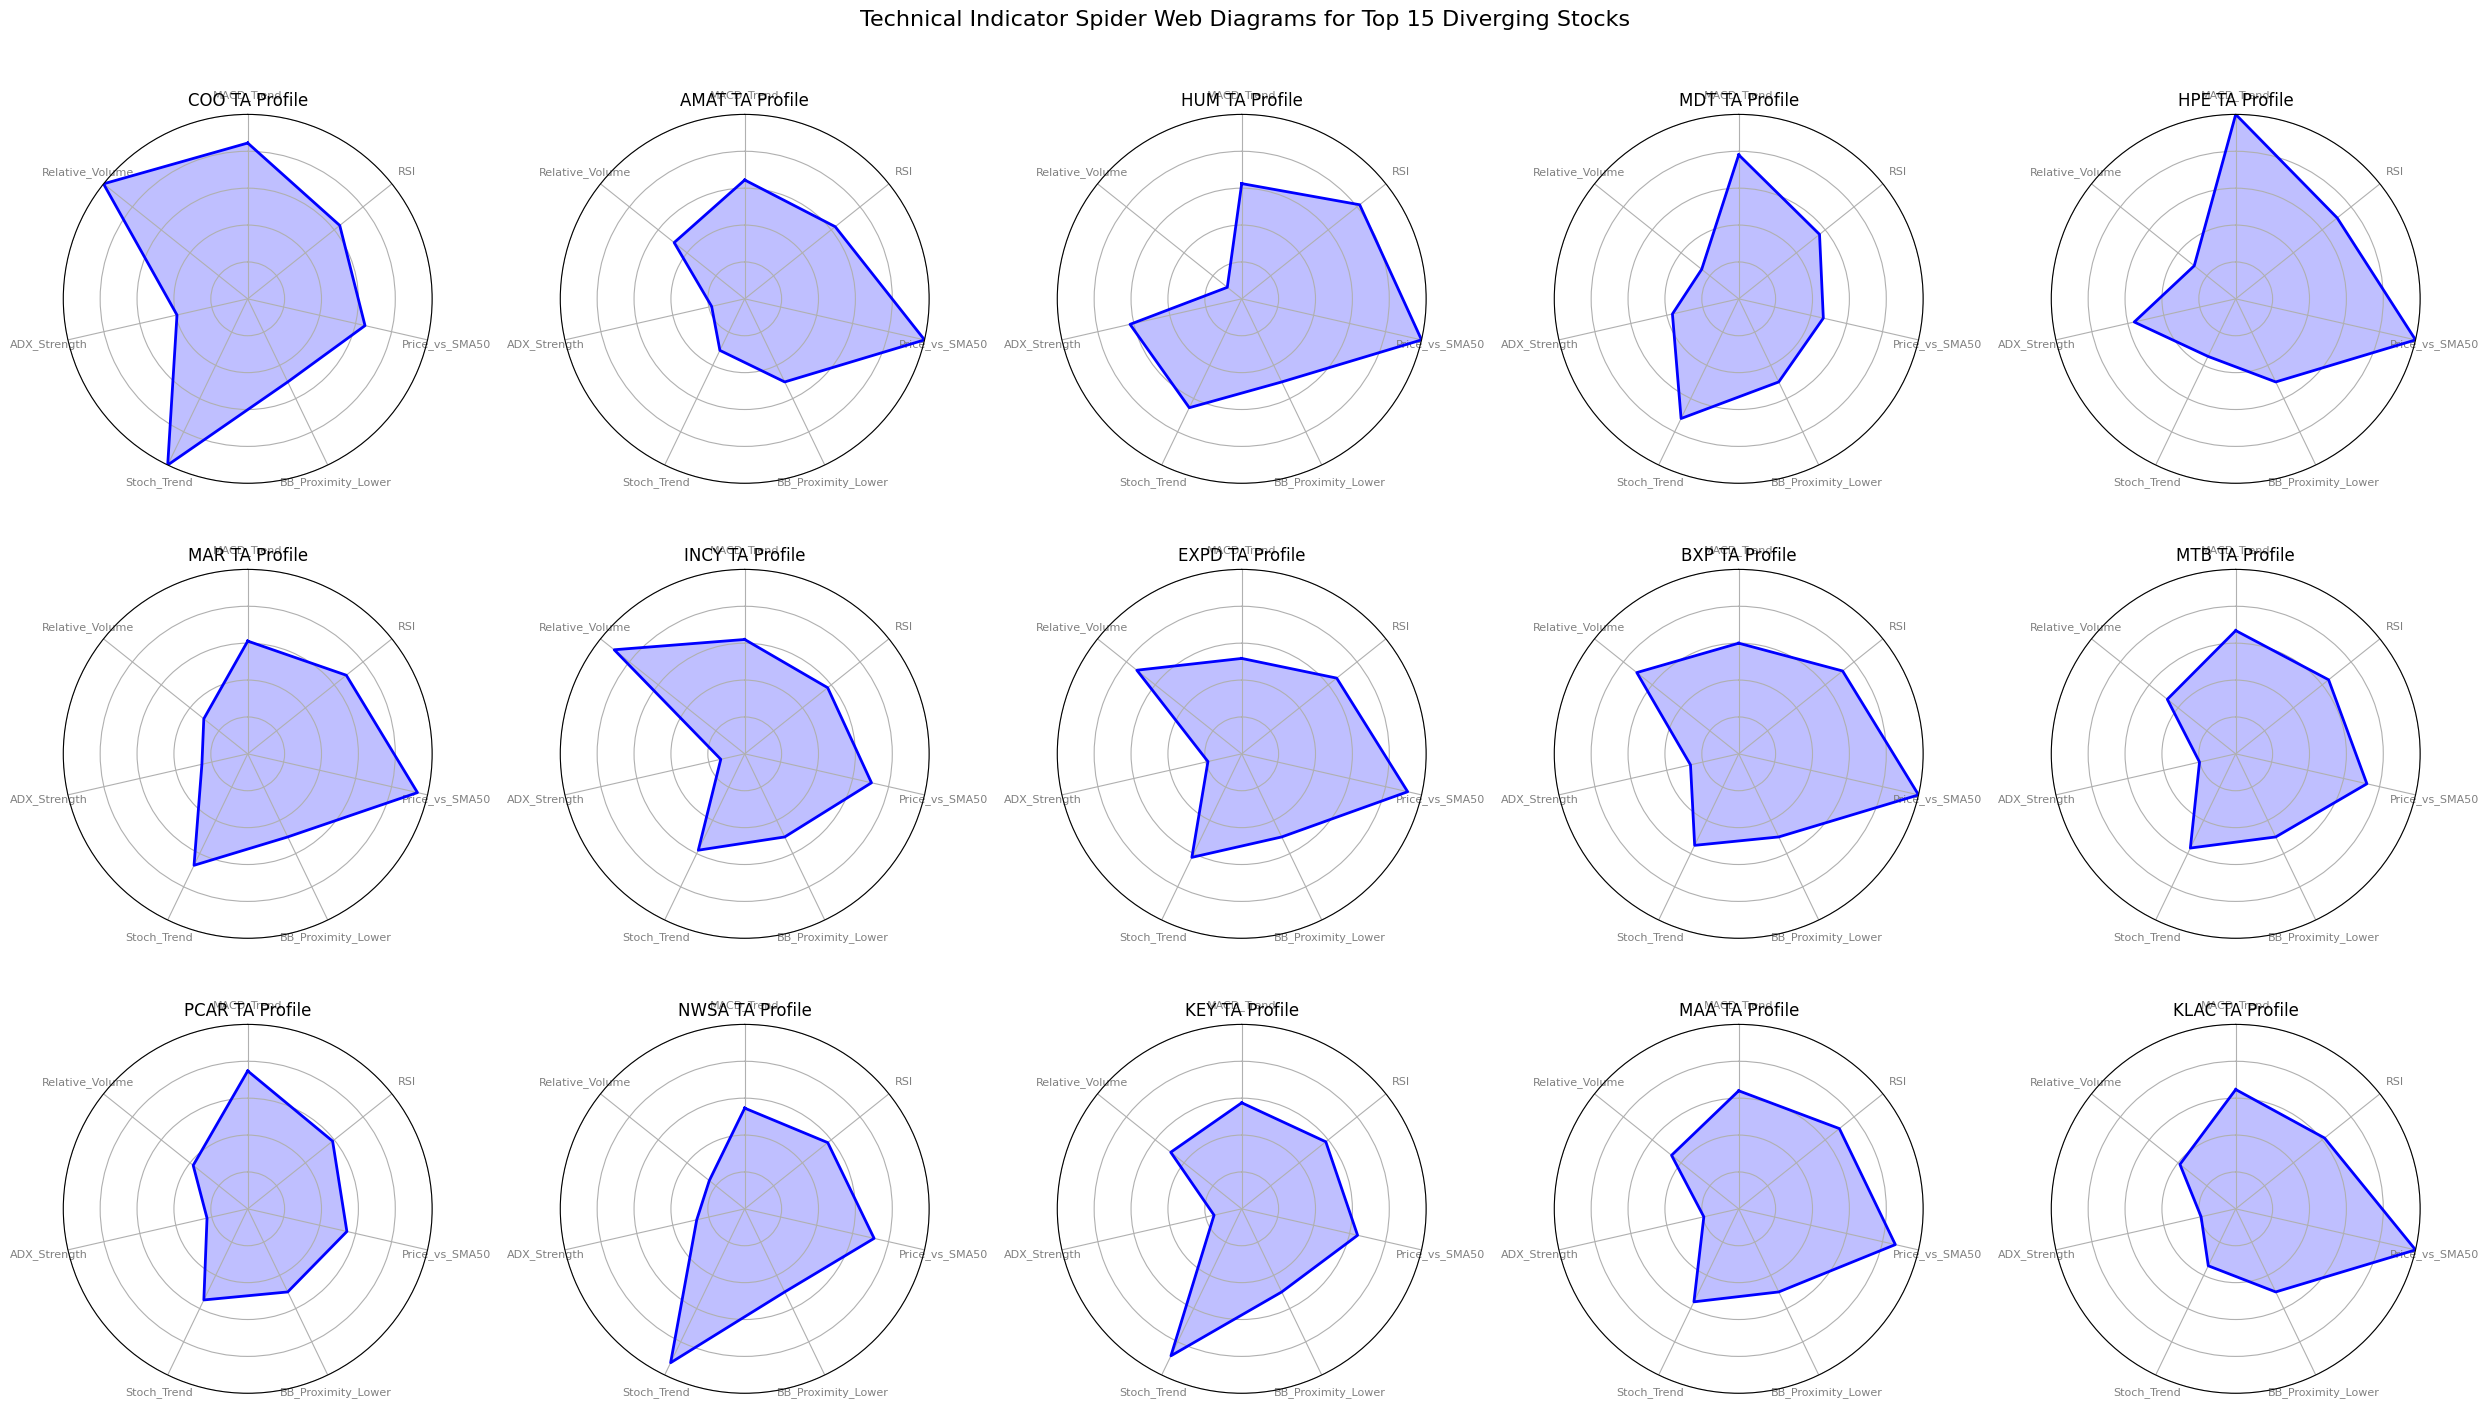

In [ ]:
from math import pi

# Create a figure for all spider charts
fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(25, 15), subplot_kw=dict(polar=True))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, (index, row) in enumerate(top_15_diverging_stocks.iterrows()):
    if i >= len(axes): # Stop if we run out of subplots
        break

    symbol = row['Symbol']

    if symbol in all_stocks_data:
        df_stock = all_stocks_data[symbol].copy() # Get the raw data for the stock
        df_stock = standardize_yfinance_df_columns(df_stock) # Standardize columns
        normalized_indicators = get_normalized_indicators(df_stock, symbol)

        if normalized_indicators is not None:
            categories = list(normalized_indicators.keys())
            values = list(normalized_indicators.values())

            # Ensure the plot closes the circle
            categories = categories + [categories[0]]
            values = values + [values[0]]

            # Calculate angle for each category
            angles = [n / float(len(categories) - 1) * 2 * pi for n in range(len(categories))]

            # Plotting
            ax = axes[i]
            ax.set_theta_offset(pi / 2)
            ax.set_theta_direction(-1)

            # Draw one axe per variable + add labels labels yet
            ax.set_xticks(angles[:-1])
            ax.set_xticklabels(categories[:-1], color='grey', size=8)

            # Draw ylabels
            ax.set_yticklabels([]) # Hide radial labels for cleaner look
            ax.set_ylim(0, 1)

            ax.plot(angles, values, linewidth=2, linestyle='solid', label=symbol, color='blue')
            ax.fill(angles, values, 'blue', alpha=0.25)
            ax.set_title(f'{symbol} TA Profile', size=12, color='black', position=(0.5, 1.1))
        else:
            axes[i].set_title(f'{symbol} - No Data', size=12, color='red')
            axes[i].axis('off') # Turn off axis for empty plot
    else:
        axes[i].set_title(f'{symbol} - Data Missing', size=12, color='red')
        axes[i].axis('off') # Turn off axis for empty plot

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

fig.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent overlap
fig.suptitle('Technical Indicator Spider Web Diagrams for Top 15 Diverging Stocks', size=16, y=0.98)
plt.show()

In [ ]:

import pandas as pd
import yfinance as yf
import pandas_ta as ta

# 1. Define portfolio tickers directly from your snapshot
portfolio_tickers = [
    "ACHR", "AVGO", "BRK-B", "BSX", "CERT", "CMPS", "CODX",
    "CRM", "ENLV", "IBKR", "JOBY", "LUNG", "MDT", "META",
    "MSFT", "NASA", "NFLX", "SCHW"
]

def analyze_portfolio_metrics(tickers, period="6m"):
    analysis_results = []

    for ticker in tickers:
        try:
            # Download historical data
            df = yf.download(ticker, period=period, progress=False)
            if df.empty or len(df) < 20:
                continue

            # Flatten column multi-index if returned by yfinance
            if isinstance(df.columns, pd.MultiIndex):
                df.columns = df.columns.get_level_values(0)

            # Calculate Core Technical Data via pandas_ta
            df['RSI'] = ta.rsi(df['Close'], length=14)

            # Calculate MACD
            macd_df = ta.macd(df['Close'], fast=12, slow=26, signal=9)
            df['MACD'] = macd_df.iloc[:, 0]
            df['MACD_Signal'] = macd_df.iloc[:, 1]
            df['MACD_Hist'] = macd_df.iloc[:, 2]

            # Calculate Moving Averages
            df['SMA_20'] = ta.sma(df['Close'], length=20)
            df['SMA_50'] = ta.sma(df['Close'], length=50)
            df['SMA_200'] = ta.sma(df['Close'], length=200)

            # Calculate Money Flow Index (MFI)
            df['MFI'] = ta.mfi(df['High'], df['Low'], df['Close'], df['Volume'], length=14)

            # Get latest values
            latest = df.iloc[-1]
            prev = df.iloc[-2]

            # Trend evaluations
            price_vs_sma50 = "Above" if latest['Close'] > latest['SMA_50'] else "Below"
            macd_cross = "Bullish Crossover" if (latest['MACD'] > latest['MACD_Signal'] and prev['MACD'] <= prev['MACD_Signal']) \
                         else "Bearish Crossover" if (latest['MACD'] < latest['MACD_Signal'] and prev['MACD'] >= prev['MACD_Signal']) \
                         else "No Cross"

            # Calculate distance from 50-day moving average (Volatility / Breakaway proxy)
            pct_dist_sma50 = ((latest['Close'] - latest['SMA_50']) / latest['SMA_50']) * 100

            analysis_results.append({
                "Ticker": ticker,
                "Last Price": round(latest['Close'], 2),
                "RSI (14)": round(latest['RSI'], 2) if not pd.isna(latest['RSI']) else None,
                "MFI (14)": round(latest['MFI'], 2) if not pd.isna(latest['MFI']) else None,
                "MACD Status": macd_cross,
                "Price vs SMA50": price_vs_sma50,
                "Dist from SMA50 (%)": round(pct_dist_sma50, 2) if not pd.isna(pct_dist_sma50) else 0.0
            })

        except Exception as e:
            print(f"Could not process asset {ticker}: {e}")

    return pd.DataFrame(analysis_results)

# Execute the analysis
portfolio_df = analyze_portfolio_metrics(portfolio_tickers)

# Sort by absolute distance from the mean trend to highlight index break-apart candidates
portfolio_df['Abs_Dist'] = portfolio_df['Dist from SMA50 (%)'].abs()
portfolio_df = portfolio_df.sort_values(by='Abs_Dist', ascending=False).drop(columns=['Abs_Dist'])

print("\n=== PORTFOLIO TECHNICAL & MONEY FLOW SUMMARY ===")
print(portfolio_df.to_string(index=False))

ModuleNotFoundError: No module named 'pandas_ta'

### Identifying Top Trading Stocks by Volume

To identify 'top trading stocks', we will consider those with the highest average daily trading volume over the analyzed period. This can indicate high liquidity and investor interest. We will calculate the average volume for each stock and then select the top 15.

In [ ]:
import pandas as pd

volume_analysis_results = []

print("\nCalculating average daily volume for each stock...")

for symbol, df_raw in all_stocks_data.items():
    df = standardize_yfinance_df_columns(df_raw.copy()) # Ensure columns are standardized

    if 'Volume' in df.columns and not df.empty:
        avg_volume = df['Volume'].mean()
        volume_analysis_results.append({'Symbol': symbol, 'Average_Daily_Volume': avg_volume})

if volume_analysis_results:
    volume_df = pd.DataFrame(volume_analysis_results)
    top_15_volume_stocks = volume_df.sort_values(by='Average_Daily_Volume', ascending=False).head(15)

    print("\nTop 15 Stocks by Average Daily Trading Volume:")
    display(top_15_volume_stocks)
else:
    print("No volume data available for analysis.")


Calculating average daily volume for each stock...

Top 15 Stocks by Average Daily Trading Volume:


,Symbol,Average_Daily_Volume
0,NVDA,1.767777e+08
16,INTC,1.108133e+08
8,TSLA,7.629933e+07
173,F,7.106346e+07
25,PLTR,5.442308e+07
1,AAPL,4.973457e+07
78,PFE,4.835808e+07
11,AMD,4.728323e+07
3,AMZN,4.575439e+07
170,WBD,4.261568e+07


### Technical Analysis Spider Web Diagrams for Top 15 Volume Stocks

Now, let's visualize the technical profile of these top 15 stocks by average daily trading volume using spider web diagrams. This will provide a comprehensive view of their technical indicators.

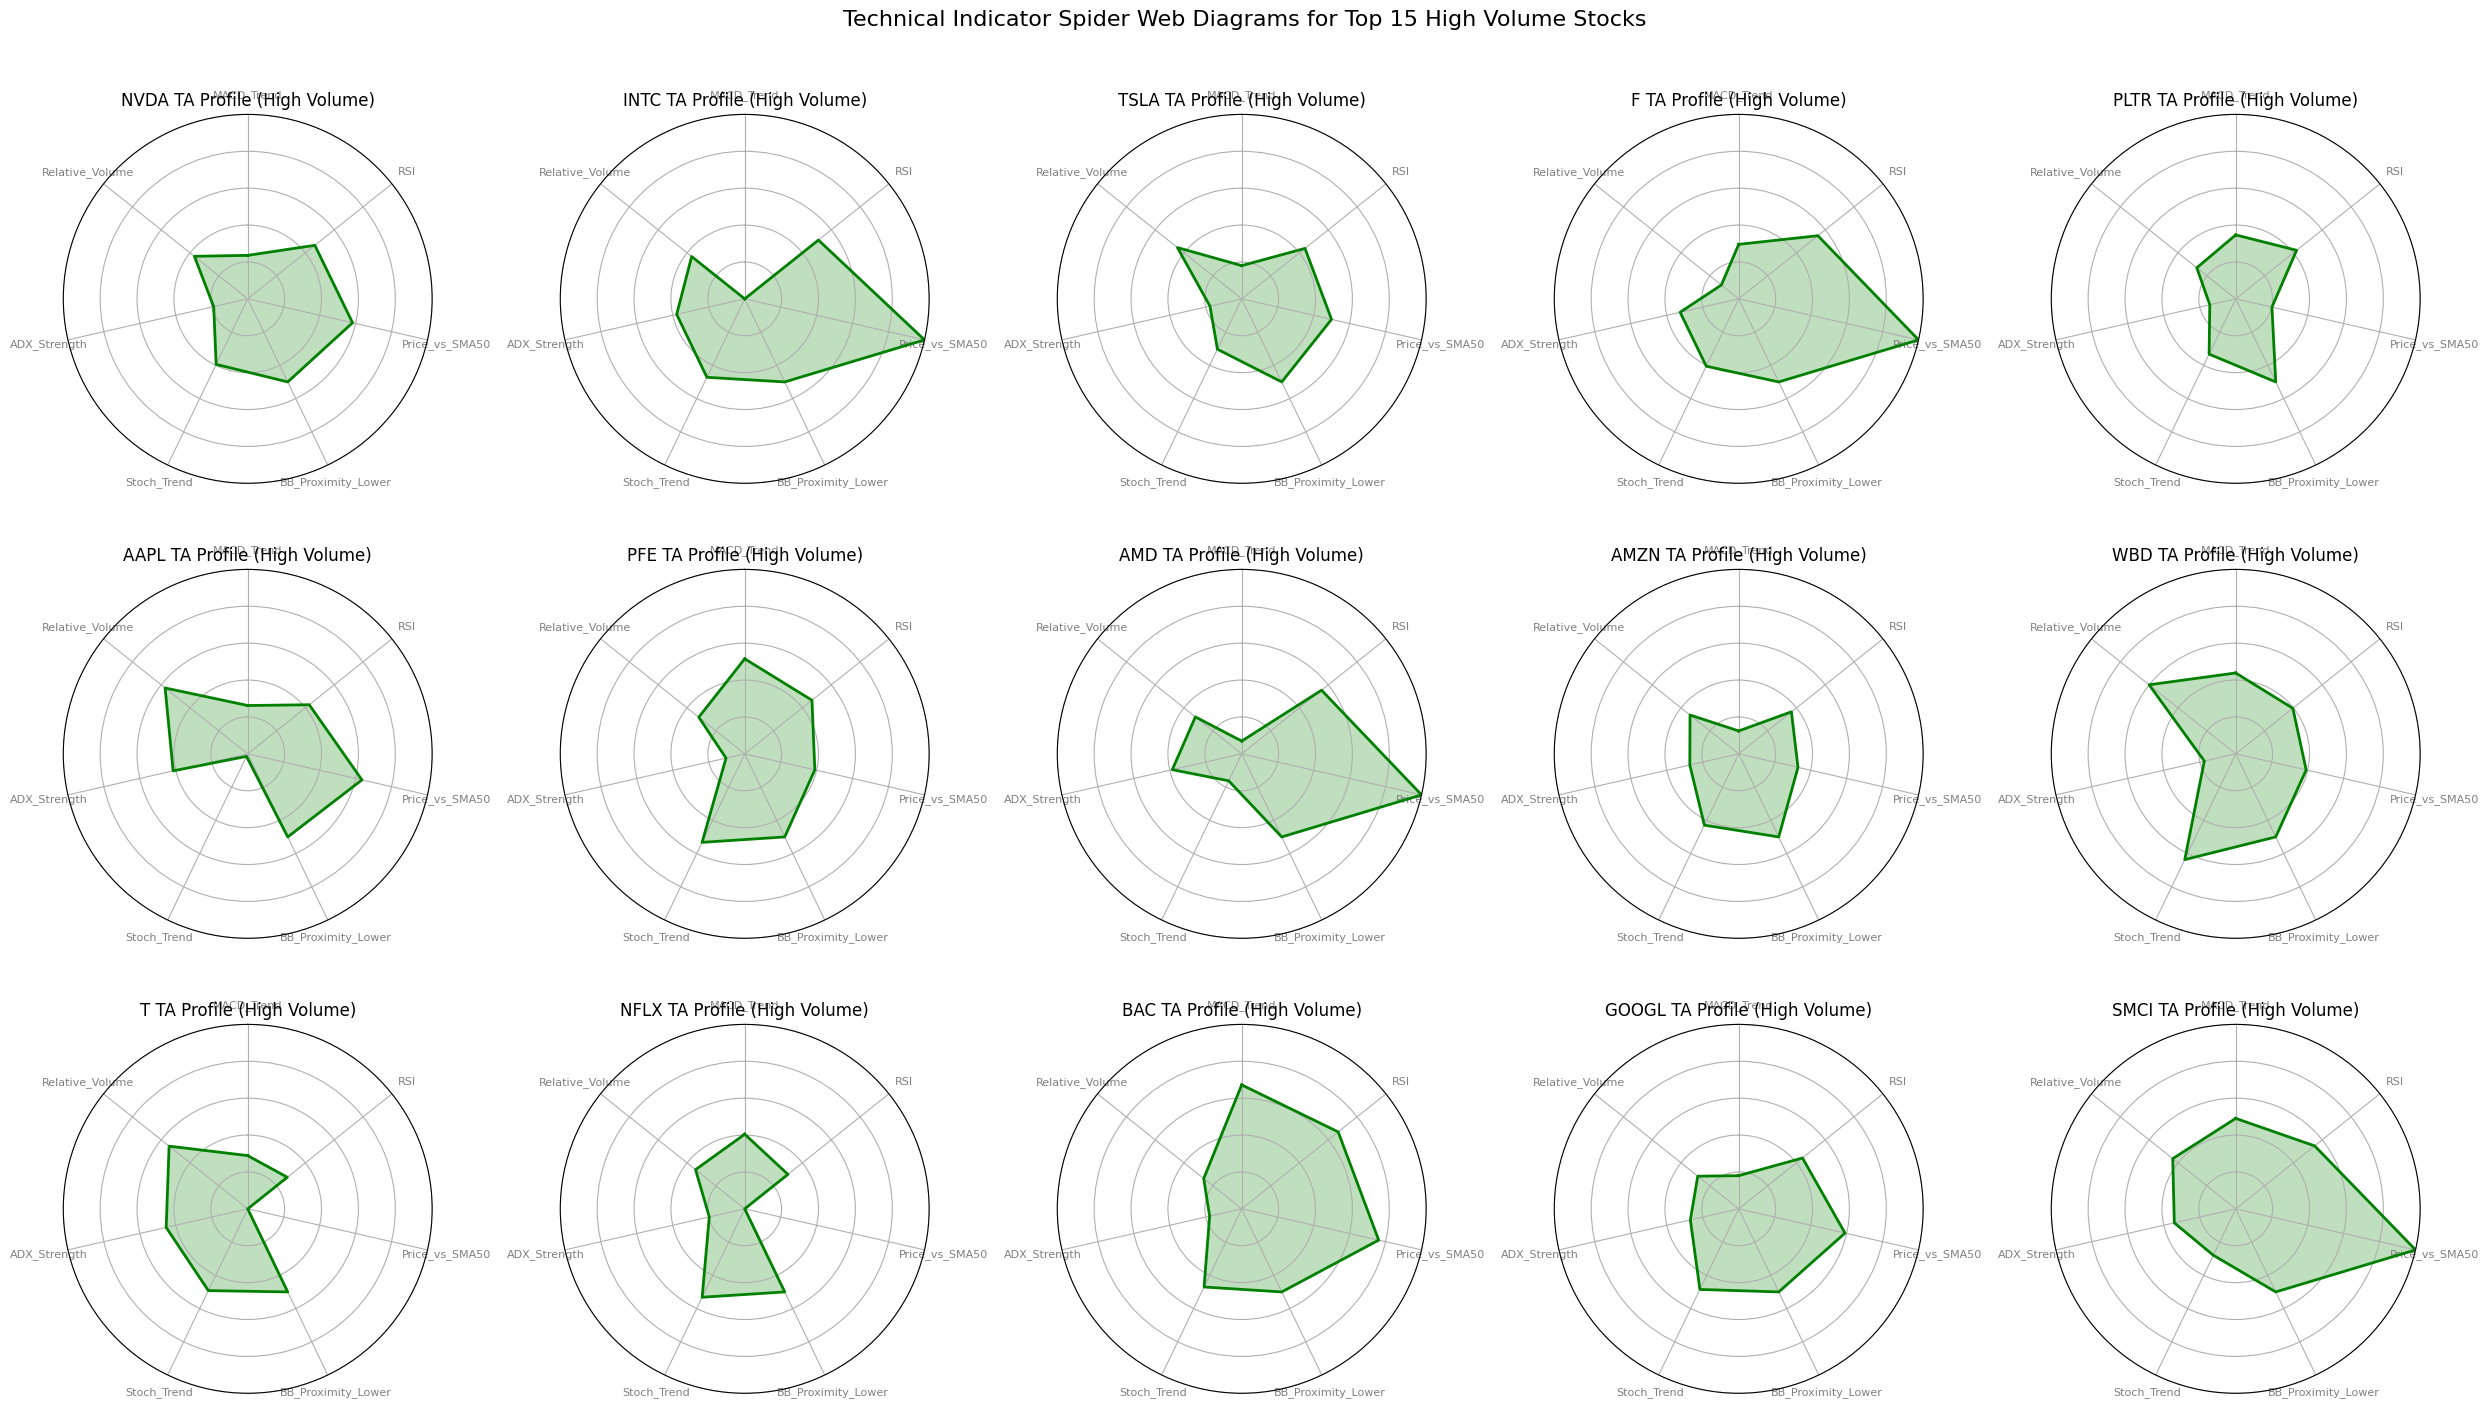

In [ ]:
from math import pi
import matplotlib.pyplot as plt

# Create a figure for all spider charts for top volume stocks
fig_volume, axes_volume = plt.subplots(nrows=3, ncols=5, figsize=(25, 15), subplot_kw=dict(polar=True))
axes_volume = axes_volume.flatten() # Flatten the 2D array of axes for easy iteration

for i, (index, row) in enumerate(top_15_volume_stocks.iterrows()):
    if i >= len(axes_volume): # Stop if we run out of subplots
        break

    symbol = row['Symbol']

    if symbol in all_stocks_data:
        df_stock = all_stocks_data[symbol].copy() # Get the raw data for the stock
        df_stock = standardize_yfinance_df_columns(df_stock) # Standardize columns
        normalized_indicators = get_normalized_indicators(df_stock, symbol)

        if normalized_indicators is not None:
            categories = list(normalized_indicators.keys())
            values = list(normalized_indicators.values())

            # Ensure the plot closes the circle
            categories = categories + [categories[0]]
            values = values + [values[0]]

            # Calculate angle for each category
            angles = [n / float(len(categories) - 1) * 2 * pi for n in range(len(categories))]

            # Plotting
            ax = axes_volume[i]
            ax.set_theta_offset(pi / 2)
            ax.set_theta_direction(-1)

            # Draw one axe per variable + add labels labels yet
            ax.set_xticks(angles[:-1])
            ax.set_xticklabels(categories[:-1], color='grey', size=8)

            # Draw ylabels
            ax.set_yticklabels([]) # Hide radial labels for cleaner look
            ax.set_ylim(0, 1)

            ax.plot(angles, values, linewidth=2, linestyle='solid', label=symbol, color='green') # Using 'green' for volume charts
            ax.fill(angles, values, 'green', alpha=0.25)
            ax.set_title(f'{symbol} TA Profile (High Volume)', size=12, color='black', position=(0.5, 1.1))
        else:
            axes_volume[i].set_title(f'{symbol} - No Data', size=12, color='red')
            axes_volume[i].axis('off') # Turn off axis for empty plot
    else:
        axes_volume[i].set_title(f'{symbol} - Data Missing', size=12, color='red')
        axes_volume[i].axis('off') # Turn off axis for empty plot

# Hide any unused subplots
for j in range(i + 1, len(axes_volume)):
    axes_volume[j].axis('off')

fig_volume.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent overlap
fig_volume.suptitle('Technical Indicator Spider Web Diagrams for Top 15 High Volume Stocks', size=16, y=0.98)
plt.show()

Now that the SPY data is loaded, to find 'top diverging stocks for investment' and perform 'technical analysis of each of them', I will need access to data for individual stocks that make up the SPY ETF. The current file likely only contains data for the SPY ETF itself.

Could you please provide:
1.  A list of individual stock symbols you're interested in?
2.  Another data source (e.g., another Excel file, a method to download data) for these individual stocks?

In [ ]:
import pandas as pd

# Assuming top_15_volume_stocks and all_stocks_data are available from previous executions

recent_performance_volume = []
lookback_days = 7

print(f"\nAnalyzing price change and average volume for the last {lookback_days} trading days for top volume stocks...")

for index, row in top_15_volume_stocks.iterrows():
    symbol = row['Symbol']

    if symbol in all_stocks_data:
        df_stock = all_stocks_data[symbol].copy()
        df_stock = standardize_yfinance_df_columns(df_stock) # Ensure columns are standardized

        if not df_stock.empty and len(df_stock) >= lookback_days:
            # Get the last 'lookback_days' of data
            recent_data = df_stock.tail(lookback_days)

            # Price Change
            start_price = recent_data['Adj Close'].iloc[0]
            end_price = recent_data['Adj Close'].iloc[-1]
            price_change_percent = ((end_price - start_price) / start_price) * 100

            # Average Volume for the last 'lookback_days'
            avg_recent_volume = recent_data['Volume'].mean()

            recent_performance_volume.append({
                'Symbol': symbol,
                'Last_7D_Price_Change_%': price_change_percent,
                'Last_7D_Avg_Volume': avg_recent_volume
            })
        elif not df_stock.empty and len(df_stock) < lookback_days:
            print(f"Warning: Not enough data ({len(df_stock)} days) for {symbol} to calculate {lookback_days}-day metrics.")
        else:
            print(f"No data available for {symbol}.")
    else:
        print(f"Data for {symbol} not found in all_stocks_data.")

if recent_performance_volume:
    recent_analysis_df = pd.DataFrame(recent_performance_volume)
    print(f"\nRecent Performance and Volume for Top {len(recent_analysis_df)} Trading Stocks (Last {lookback_days} Trading Days):")
    display(recent_analysis_df.set_index('Symbol'))
else:
    print("No recent performance and volume data to display for top trading stocks.")


Analyzing price change and average volume for the last 7 trading days for top volume stocks...

Recent Performance and Volume for Top 15 Trading Stocks (Last 7 Trading Days):


,Last_7D_Price_Change_%,Last_7D_Avg_Volume
Symbol,,
NVDA,-7.099017,1.820712e+08
INTC,-1.289677,1.241120e+08
TSLA,-4.616719,4.798739e+07
F,-10.102222,6.132094e+07
PLTR,-17.790220,4.093563e+07
AAPL,-5.145118,5.748203e+07
PFE,0.273124,3.408116e+07
AMD,-6.786504,3.226674e+07
AMZN,-6.533724,4.518403e+07


In [ ]:
import pandas as pd
import numpy as np

# Helper function to standardize DataFrame columns from yfinance
def standardize_yfinance_df_columns(df):
    if isinstance(df.columns, pd.MultiIndex):
        new_columns = []
        for col_pair in df.columns:
            # Common yfinance MultiIndex patterns: ('Adj Close', 'Symbol'), ('Close', 'Symbol'), etc.
            if 'Adj Close' in col_pair: # Prioritize 'Adj Close'
                new_columns.append('Adj Close')
            elif 'Close' in col_pair: # Use 'Close' if 'Adj Close' not explicit in MultiIndex
                new_columns.append('Close')
            elif 'Volume' in col_pair:
                new_columns.append('Volume')
            elif 'Open' in col_pair:
                new_columns.append('Open')
            elif 'High' in col_pair:
                new_columns.append('High')
            elif 'Low' in col_pair:
                new_columns.append('Low')
            else:
                # Fallback for any other unexpected MultiIndex columns
                new_columns.append('_'.join(filter(None, col_pair)))
        df.columns = new_columns

    # After flattening, ensure 'Adj Close' and 'Close' are consistent
    # If 'Close' is present but 'Adj Close' is not (common with auto_adjust=True),
    # treat 'Close' as the adjusted price.
    if 'Close' in df.columns and 'Adj Close' not in df.columns:
        df['Adj Close'] = df['Close']
    # If 'Adj Close' is present but 'Close' is not, make 'Close' point to 'Adj Close'
    # for compatibility with calculate_trading_score function
    elif 'Adj Close' in df.columns and 'Close' not in df.columns:
        df['Close'] = df['Adj Close']

    # Also ensure 'Volume' exists for the scoring function
    if 'volume' in df.columns: # Sometimes yfinance returns 'volume' lowercased
        df.rename(columns={'volume': 'Volume'}, inplace=True)

    return df

# Re-define top_15_volume_stocks as it was not defined in the current execution context
# This code snippet is copied from cell 507e5333
volume_analysis_results = []

for symbol, df_raw in all_stocks_data.items():
    df = standardize_yfinance_df_columns(df_raw.copy()) # Ensure columns are standardized

    if 'Volume' in df.columns and not df.empty:
        avg_volume = df['Volume'].mean()
        volume_analysis_results.append({'Symbol': symbol, 'Average_Daily_Volume': avg_volume})

if volume_analysis_results:
    volume_df = pd.DataFrame(volume_analysis_results)
    top_15_volume_stocks = volume_df.sort_values(by='Average_Daily_Volume', ascending=False).head(15)
else:
    # Handle case where no volume data is available (shouldn't happen if all_stocks_data is populated)
    top_15_volume_stocks = pd.DataFrame()
    print("No volume data available for analysis, 'top_15_volume_stocks' is empty.")


lookback_days = 7       # recent window
baseline_days = 20      # comparison window

results = []

print(f"\nAnalyzing liquidity movement using last {lookback_days} trading days vs prior {baseline_days} trading days...")

for _, row in top_15_volume_stocks.iterrows():
    symbol = row["Symbol"]

    if symbol not in all_stocks_data:
        print(f"Data for {symbol} not found in all_stocks_data.")
        continue

    df_stock = all_stocks_data[symbol].copy()
    df_stock = standardize_yfinance_df_columns(df_stock)

    if df_stock.empty:
        print(f"No data available for {symbol}.")
        continue

    required_days = lookback_days + baseline_days
    if len(df_stock) < required_days:
        print(f"Warning: Not enough data ({len(df_stock)} days) for {symbol}. Need at least {required_days}.")
        continue

    df_stock = df_stock.tail(required_days).reset_index(drop=True)

    recent = df_stock.tail(lookback_days)
    baseline = df_stock.iloc[:-lookback_days]

    # Price change over recent window
    start_price = recent["Adj Close"].iloc[0]
    end_price = recent["Adj Close"].iloc[-1]
    price_change_pct = ((end_price - start_price) / start_price) * 100 if start_price != 0 else np.nan

    # Volume metrics
    recent_avg_volume = recent["Volume"].mean()
    baseline_avg_volume = baseline["Volume"].tail(baseline_days).mean()
    relative_volume = recent_avg_volume / baseline_avg_volume if baseline_avg_volume and baseline_avg_volume != 0 else np.nan

    # Dollar volume metrics
    recent_dollar_volume = (recent["Close"] * recent["Volume"]).mean()
    baseline_dollar_volume = (baseline["Close"].tail(baseline_days) * baseline["Volume"].tail(baseline_days)).mean()
    dollar_volume_change_pct = (
        ((recent_dollar_volume - baseline_dollar_volume) / baseline_dollar_volume) * 100
        if baseline_dollar_volume and baseline_dollar_volume != 0 else np.nan
    )

    # Simple liquidity shift score:
    # positive = liquidity flowing in, negative = liquidity flowing out
    liquidity_shift_score = (
        (relative_volume - 1) * 100 if pd.notna(relative_volume) else np.nan
    )

    # Optional directional interpretation
    if pd.notna(price_change_pct) and pd.notna(relative_volume):
        if price_change_pct > 0 and relative_volume > 1:
            flow_state = "Accumulation / Liquidity Inflow"
        elif price_change_pct < 0 and relative_volume > 1:
            flow_state = "Distribution / Liquidity Exit"
        else:
            flow_state = "Neutral / Mixed"
    else:
        flow_state = "Unknown"

    results.append({
        "Symbol": symbol,
        "Recent_Price_Change_%": price_change_pct,
        "Recent_Avg_Volume": recent_avg_volume,
        "Baseline_Avg_Volume": baseline_avg_volume,
        "Relative_Volume": relative_volume,
        "Recent_Avg_Dollar_Volume": recent_dollar_volume,
        "Baseline_Avg_Dollar_Volume": baseline_dollar_volume,
        "Dollar_Volume_Change_%": dollar_volume_change_pct,
        "Liquidity_Shift_Score": liquidity_shift_score,
        "Interpretation": flow_state
    })

if results:
    liquidity_df = pd.DataFrame(results)

    # Rank by strongest liquidity inflow
    liquidity_inflow = liquidity_df.sort_values(
        by=["Liquidity_Shift_Score", "Dollar_Volume_Change_%"],
        ascending=False
    )

    print("\nStocks with the strongest liquidity inflow:")
    display(liquidity_inflow.set_index("Symbol"))

    # Rank by strongest liquidity outflow
    liquidity_outflow = liquidity_df.sort_values(
        by=["Liquidity_Shift_Score", "Dollar_Volume_Change_%"] , # Corrected column name here
        ascending=True
    )

    print("\nStocks with the strongest liquidity outflow:")
    display(liquidity_outflow.set_index("Symbol"))
else:
    print("No liquidity movement data to display.")


Analyzing liquidity movement using last 7 trading days vs prior 20 trading days...

Stocks with the strongest liquidity inflow:


,Recent_Price_Change_%,Recent_Avg_Volume,Baseline_Avg_Volume,Relative_Volume,Recent_Avg_Dollar_Volume,Baseline_Avg_Dollar_Volume,Dollar_Volume_Change_%,Liquidity_Shift_Score,Interpretation
Symbol,,,,,,,,,
WBD,-2.532112,2.591380e+07,17375820.0,1.491371,6.913514e+08,4.711924e+08,46.723782,49.137134,Distribution / Liquidity Exit
GOOGL,-3.159767,3.907024e+07,27343930.0,1.428845,1.428446e+10,1.067392e+10,33.825744,42.884519,Distribution / Liquidity Exit
T,-7.494909,5.165051e+07,36849050.0,1.401678,1.198411e+09,9.226257e+08,29.891354,40.167831,Distribution / Liquidity Exit
AAPL,-5.145118,5.748203e+07,49064320.0,1.171565,1.752294e+10,1.457534e+10,20.223201,17.156477,Distribution / Liquidity Exit
AMZN,-6.533724,4.518403e+07,39514470.0,1.143481,1.134910e+10,1.062703e+10,6.794593,14.348057,Distribution / Liquidity Exit
NFLX,-5.171805,3.756481e+07,33260240.0,1.129421,3.102713e+09,2.926688e+09,6.014460,12.942102,Distribution / Liquidity Exit
NVDA,-7.099017,1.820712e+08,166242035.0,1.095217,3.909589e+10,3.587074e+10,8.991034,9.521733,Distribution / Liquidity Exit
BAC,6.198318,3.969536e+07,36544685.0,1.086214,2.104994e+09,1.865406e+09,12.843756,8.621424,Accumulation / Liquidity Inflow
SMCI,-13.310583,4.572891e+07,45571630.0,1.003451,2.078981e+09,1.600978e+09,29.856940,0.345136,Distribution / Liquidity Exit



Stocks with the strongest liquidity outflow:


,Recent_Price_Change_%,Recent_Avg_Volume,Baseline_Avg_Volume,Relative_Volume,Recent_Avg_Dollar_Volume,Baseline_Avg_Dollar_Volume,Dollar_Volume_Change_%,Liquidity_Shift_Score,Interpretation
Symbol,,,,,,,,,
F,-10.102222,6.132094e+07,82322710.0,0.744885,9.616543e+08,1.160154e+09,-17.109771,-25.511511,Neutral / Mixed
AMD,-6.786504,3.226674e+07,39790155.0,0.810923,1.613961e+10,1.727841e+10,-6.590926,-18.907723,Neutral / Mixed
INTC,-1.289677,1.241120e+08,142076115.0,0.873560,1.340998e+10,1.636295e+10,-18.046650,-12.644018,Neutral / Mixed
PLTR,-17.790220,4.093563e+07,45059515.0,0.908479,5.917196e+09,6.265705e+09,-5.562170,-9.152088,Neutral / Mixed
TSLA,-4.616719,4.798739e+07,52580980.0,0.912638,1.962262e+10,2.216479e+10,-11.469413,-8.736228,Neutral / Mixed
PFE,0.273124,3.408116e+07,35772205.0,0.952727,8.743074e+08,9.256905e+08,-5.550791,-4.727268,Neutral / Mixed
SMCI,-13.310583,4.572891e+07,45571630.0,1.003451,2.078981e+09,1.600978e+09,29.856940,0.345136,Distribution / Liquidity Exit
BAC,6.198318,3.969536e+07,36544685.0,1.086214,2.104994e+09,1.865406e+09,12.843756,8.621424,Accumulation / Liquidity Inflow
NVDA,-7.099017,1.820712e+08,166242035.0,1.095217,3.909589e+10,3.587074e+10,8.991034,9.521733,Distribution / Liquidity Exit


In [ ]:
I

## Analyze Liquidity for a Specific Stock

In [ ]:
def analyze_liquidity_for_ticker(symbol, all_stocks_data, lookback_days=7, baseline_days=20):
    """
    Analyzes liquidity movement for a single stock ticker, incorporating technical analysis.

    Args:
        symbol (str): The stock ticker symbol.
        all_stocks_data (dict): A dictionary containing historical data for all stocks.
        lookback_days (int): The number of recent trading days for analysis.
        baseline_days (int): The number of prior trading days for comparison.

    Returns:
        dict: A dictionary containing liquidity and technical analysis results, or None if data is insufficient.
    """
    if symbol not in all_stocks_data:
        print(f"Data for {symbol} not found in all_stocks_data.")
        return None

    df_stock = all_stocks_data[symbol].copy()
    df_stock = standardize_yfinance_df_columns(df_stock)

    if df_stock.empty:
        print(f"No data available for {symbol}.")
        return None

    required_days = lookback_days + baseline_days
    if len(df_stock) < required_days:
        print(f"Warning: Not enough data ({len(df_stock)} days) for {symbol}. Need at least {required_days}.")
        return None

    # Ensure df_stock has enough data for technical indicators after initial filtering
    # The technical analysis functions (calculate_technical_metrics) handle their own NaN dropping,
    # but we need enough raw data for them to work.
    # Let's ensure at least 50 days (for SMA_50) of data are passed.
    if len(df_stock) < 50: # Arbitrary minimum for most indicators to work
        print(f"Warning: Not enough historical data ({len(df_stock)} days) for {symbol} to calculate reliable technical indicators. Skipping extensive analysis.")
        return None

    df_stock_recent_for_liquidity = df_stock.tail(required_days).reset_index(drop=True)

    recent = df_stock_recent_for_liquidity.tail(lookback_days)
    baseline = df_stock_recent_for_liquidity.iloc[:-lookback_days]

    # Price change over recent window
    start_price = recent["Adj Close"].iloc[0]
    end_price = recent["Adj Close"].iloc[-1]
    price_change_pct = ((end_price - start_price) / start_price) * 100 if start_price != 0 else np.nan

    # Volume metrics
    recent_avg_volume = recent["Volume"].mean()
    baseline_avg_volume = baseline["Volume"].tail(baseline_days).mean()
    relative_volume = recent_avg_volume / baseline_avg_volume if baseline_avg_volume and baseline_avg_volume != 0 else np.nan

    # Dollar volume metrics
    recent_dollar_volume = (recent["Close"] * recent["Volume"]).mean()
    baseline_dollar_volume = (baseline["Close"].tail(baseline_days) * baseline["Volume"].tail(baseline_days)).mean()
    dollar_volume_change_pct = (
        ((recent_dollar_volume - baseline_dollar_volume) / baseline_dollar_volume) * 100
        if baseline_dollar_volume and baseline_dollar_volume != 0 else np.nan
    )

    # Simple liquidity shift score:
    # positive = liquidity flowing in, negative = liquidity flowing out
    liquidity_shift_score = (
        (relative_volume - 1) * 100 if pd.notna(relative_volume) else np.nan
    )

    # Optional directional interpretation
    if pd.notna(price_change_pct) and pd.notna(relative_volume):
        if price_change_pct > 0 and relative_volume > 1.2: # Higher bar for accumulation
            flow_state = "Accumulation / Strong Liquidity Inflow"
        elif price_change_pct > 0 and relative_volume > 1:
            flow_state = "Accumulation / Liquidity Inflow"
        elif price_change_pct < 0 and relative_volume > 1.2: # Strong selling pressure
            flow_state = "Distribution / Strong Liquidity Exit"
        elif price_change_pct < 0 and relative_volume > 1:
            flow_state = "Distribution / Liquidity Exit"
        else:
            flow_state = "Neutral / Mixed"
    else:
        flow_state = "Unknown"

    # --- Integrate Technical Analysis ---
    technical_score, normalized_indicators, _, _ = calculate_technical_metrics(df_stock, symbol)

    # --- Decision Logic ---
    decision = "Hold"
    if pd.notna(liquidity_shift_score) and pd.notna(technical_score):
        if flow_state in ("Accumulation / Strong Liquidity Inflow", "Accumulation / Liquidity Inflow") and technical_score >= 7: # Good liquidity and strong technicals
            if liquidity_shift_score > 10 and technical_score >= 8: # Very strong signals
                decision = "Strong Buy"
            else:
                decision = "Buy"
        elif flow_state in ("Distribution / Strong Liquidity Exit", "Distribution / Liquidity Exit") and technical_score <= 4: # Poor liquidity and weak technicals
            if liquidity_shift_score < -10 and technical_score <= 3: # Very weak signals
                decision = "Strong Sell"
            else:
                decision = "Sell"
        elif flow_state == "Neutral / Mixed":
            if technical_score >= 6: # Neutral liquidity but good technicals
                decision = "Consider Buy"
            elif technical_score <= 5: # Neutral liquidity but weak technicals
                decision = "Consider Sell"
            else:
                decision = "Hold"


    result = {
        "Symbol": symbol,
        "Recent_Price_Change_%": price_change_pct,
        "Recent_Avg_Volume": recent_avg_volume,
        "Baseline_Avg_Volume": baseline_avg_volume,
        "Relative_Volume": relative_volume,
        "Recent_Avg_Dollar_Volume": recent_dollar_volume,
        "Baseline_Avg_Dollar_Volume": baseline_dollar_volume,
        "Dollar_Volume_Change_%": dollar_volume_change_pct,
        "Liquidity_Shift_Score": liquidity_shift_score,
        "Interpretation": flow_state,
        "Technical_Score": technical_score,
        "Normalized_Indicators": normalized_indicators,
        "Decision": decision
    }

    return result

print("Liquidity and Technical analysis function updated and defined.")

Liquidity and Technical analysis function updated and defined.


### Example Usage


Liquidity and Technical Analysis for NVDA:


,Recent_Price_Change_%,Recent_Avg_Volume,Baseline_Avg_Volume,Relative_Volume,Recent_Avg_Dollar_Volume,Baseline_Avg_Dollar_Volume,Dollar_Volume_Change_%,Liquidity_Shift_Score,Interpretation,Technical_Score,Normalized_Indicators,Decision
Symbol,,,,,,,,,,,,
NVDA,-6.160249,1.629149e+08,176226980.0,0.924461,3.377922e+10,3.850255e+10,-12.267577,-7.553915,Neutral / Mixed,4,"{'MACD_Trend': 0, 'RSI': 0.4537619329859413, '...",Consider Sell



Technical Parameters for NVDA:
  MACD_Trend: 0.0000
  RSI: 0.4538
  Price_vs_SMA50: 0.4634
  BB_Proximity_Lower: 0.5000
  Stoch_Trend: 0.4528
  ADX_Strength: 0.1794
  Relative_Volume: 0.1118

Decision for NVDA: Consider Sell

Liquidity and Technical Analysis for T:


,Recent_Price_Change_%,Recent_Avg_Volume,Baseline_Avg_Volume,Relative_Volume,Recent_Avg_Dollar_Volume,Baseline_Avg_Dollar_Volume,Dollar_Volume_Change_%,Liquidity_Shift_Score,Interpretation,Technical_Score,Normalized_Indicators,Decision
Symbol,,,,,,,,,,,,
T,3.55731,52219100.0,39061660.0,1.336838,1.195718e+09,9.685977e+08,23.448417,33.683771,Accumulation / Strong Liquidity Inflow,7,"{'MACD_Trend': 0.3371870546022387, 'RSI': 0.42...",Buy



Technical Parameters for T:
  MACD_Trend: 0.3372
  RSI: 0.4211
  Price_vs_SMA50: 0.1666
  BB_Proximity_Lower: 0.5000
  Stoch_Trend: 0.7069
  ADX_Strength: 0.4517
  Relative_Volume: 0.3006

Decision for T: Buy

Generating spider web diagrams for selected stocks...


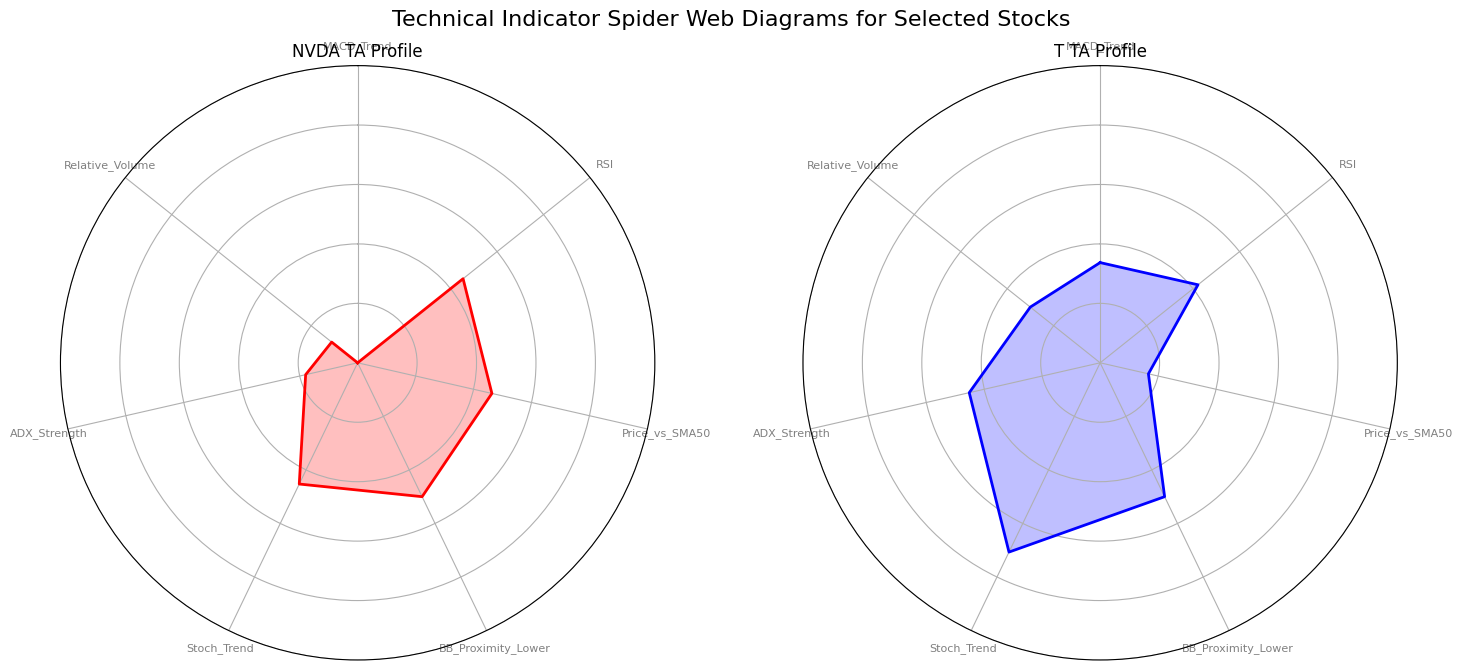

In [ ]:
# Example: Check liquidity for 'AAPL'
example_ticker = 'NVDA'
liquidity_data_aapl = analyze_liquidity_for_ticker(example_ticker, all_stocks_data)

if liquidity_data_aapl:
    print(f"\nLiquidity and Technical Analysis for {example_ticker}:")
    display(pd.DataFrame([liquidity_data_aapl]).set_index('Symbol'))
    print(f"\nTechnical Parameters for {example_ticker}:")
    for indicator, value in liquidity_data_aapl['Normalized_Indicators'].items():
        print(f"  {indicator}: {value:.4f}")
    print(f"\nDecision for {example_ticker}: {liquidity_data_aapl['Decision']}")
else:
    print(f"Could not perform liquidity and technical analysis for {example_ticker}.")

# You can change the ticker to any other stock in `all_stocks_data`
# For example, let's try 'NVDA'
example_ticker_2 = 'T'
liquidity_data_nvda = analyze_liquidity_for_ticker(example_ticker_2, all_stocks_data)

if liquidity_data_nvda:
    print(f"\nLiquidity and Technical Analysis for {example_ticker_2}:")
    display(pd.DataFrame([liquidity_data_nvda]).set_index('Symbol'))
    print(f"\nTechnical Parameters for {example_ticker_2}:")
    for indicator, value in liquidity_data_nvda['Normalized_Indicators'].items():
        print(f"  {indicator}: {value:.4f}")
    print(f"\nDecision for {example_ticker_2}: {liquidity_data_nvda['Decision']}")
else:
    print(f"Could not perform liquidity and technical analysis for {example_ticker_2}.")


from math import pi
import matplotlib.pyplot as plt

print("\nGenerating spider web diagrams for selected stocks...")

# Create a figure for the two spider charts
fig_selected, axes_selected = plt.subplots(nrows=1, ncols=2, figsize=(15, 7), subplot_kw=dict(polar=True))

stocks_to_plot = [
    (liquidity_data_aapl, 'blue' if liquidity_data_aapl and liquidity_data_aapl['Liquidity_Shift_Score'] >=0 else 'red'),
    (liquidity_data_nvda, 'blue' if liquidity_data_nvda and liquidity_data_nvda['Liquidity_Shift_Score'] >=0 else 'red')
]

for i, (data, color) in enumerate(stocks_to_plot):
    ax = axes_selected[i]
    if data and data['Normalized_Indicators']:
        symbol = data['Symbol']
        normalized_indicators = data['Normalized_Indicators']

        categories = list(normalized_indicators.keys())
        values = list(normalized_indicators.values())

        # Ensure the plot closes the circle
        categories = categories + [categories[0]]
        values = values + [values[0]]

        # Calculate angle for each category
        angles = [n / float(len(categories) - 1) * 2 * pi for n in range(len(categories))]

        # Plotting
        ax.set_theta_offset(pi / 2)
        ax.set_theta_direction(-1)

        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(categories[:-1], color='grey', size=8)

        ax.set_yticklabels([]) # Hide radial labels for cleaner look
        ax.set_ylim(0, 1)

        ax.plot(angles, values, linewidth=2, linestyle='solid', label=symbol, color=color)
        ax.fill(angles, values, color, alpha=0.25)
        ax.set_title(f'{symbol} TA Profile', size=12, color='black', position=(0.5, 1.1))
    else:
        ax.set_title(f'No Data', size=12, color='red')
        ax.axis('off') # Turn off axis for empty plot

fig_selected.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent overlap
fig_selected.suptitle('Technical Indicator Spider Web Diagrams for Selected Stocks', size=16, y=0.98)
plt.show()

### Technical Analysis Spider Web Diagrams for Stocks with Strongest Liquidity Inflow

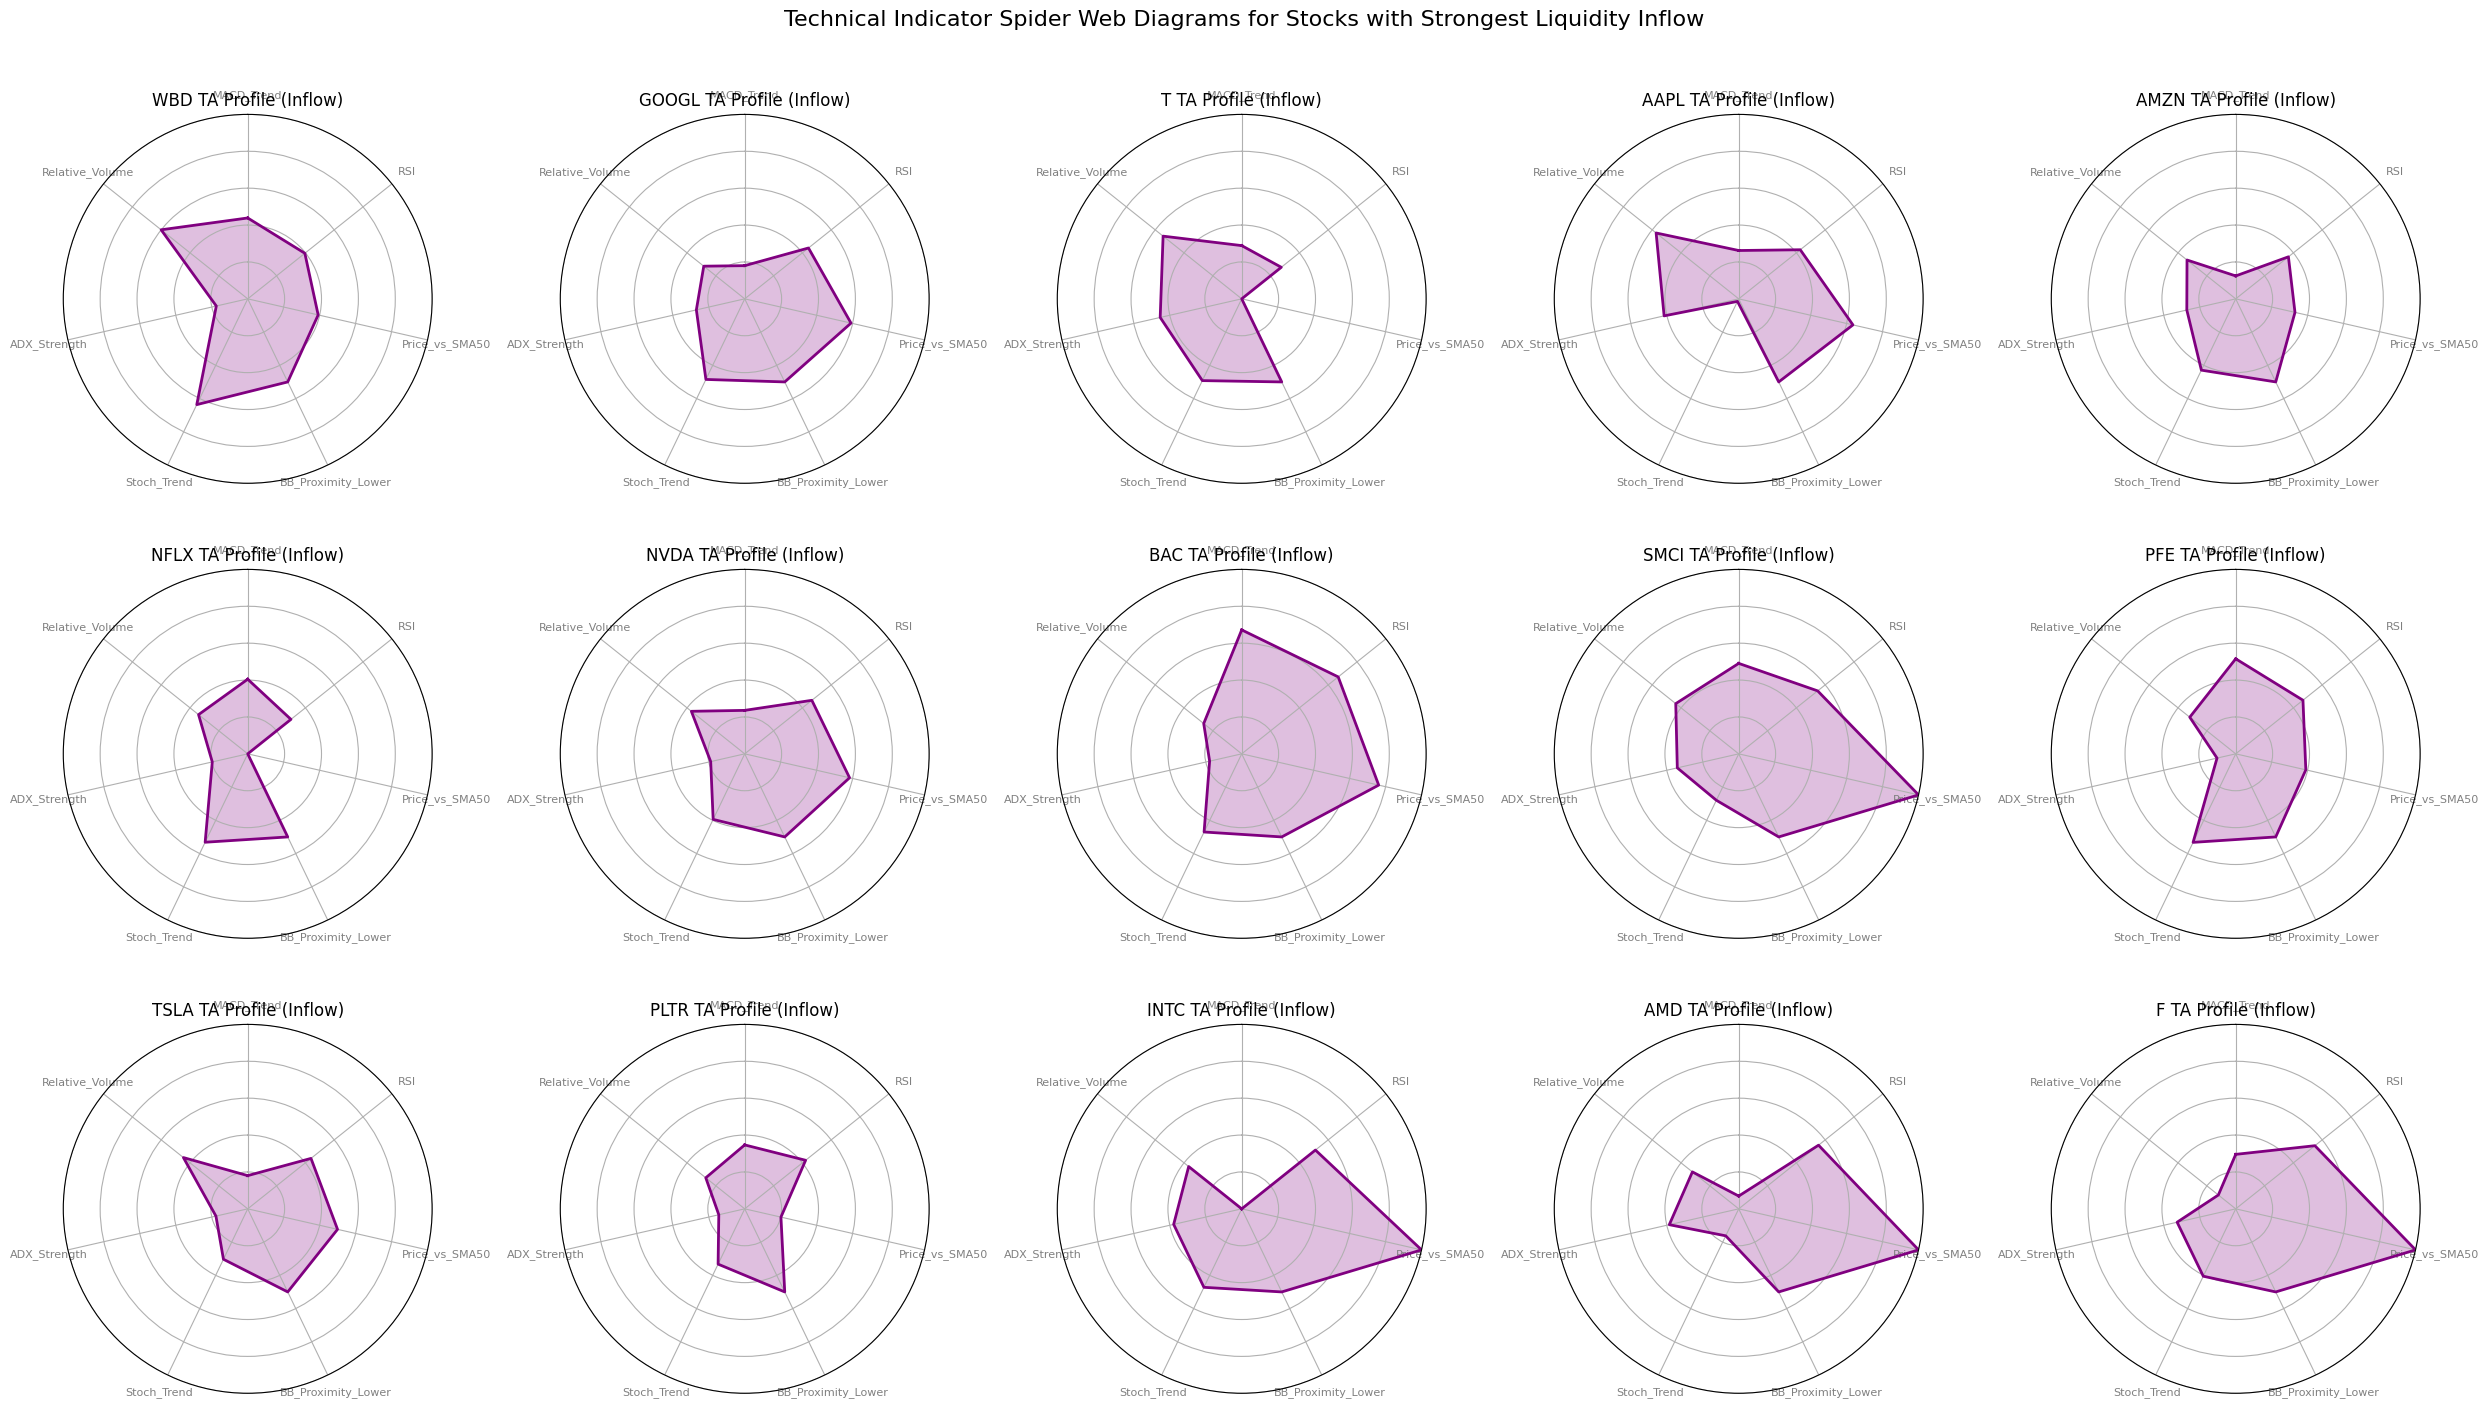

In [ ]:
from math import pi
import matplotlib.pyplot as plt

# Create a figure for all spider charts for liquidity inflow stocks
fig_inflow, axes_inflow = plt.subplots(nrows=3, ncols=5, figsize=(25, 15), subplot_kw=dict(polar=True))
axes_inflow = axes_inflow.flatten() # Flatten the 2D array of axes for easy iteration

# Ensure liquidity_inflow is a DataFrame (it was in the kernel state)
if 'liquidity_inflow' in locals() and not liquidity_inflow.empty:
    for i, (index, row) in enumerate(liquidity_inflow.iterrows()):
        if i >= len(axes_inflow): # Stop if we run out of subplots
            break

        symbol = row['Symbol']

        if symbol in all_stocks_data:
            df_stock = all_stocks_data[symbol].copy() # Get the raw data for the stock
            df_stock = standardize_yfinance_df_columns(df_stock) # Standardize columns
            normalized_indicators = get_normalized_indicators(df_stock, symbol)

            if normalized_indicators is not None:
                categories = list(normalized_indicators.keys())
                values = list(normalized_indicators.values())

                # Ensure the plot closes the circle
                categories = categories + [categories[0]]
                values = values + [values[0]]

                # Calculate angle for each category
                angles = [n / float(len(categories) - 1) * 2 * pi for n in range(len(categories))]

                # Plotting
                ax = axes_inflow[i]
                ax.set_theta_offset(pi / 2)
                ax.set_theta_direction(-1)

                # Draw one axe per variable + add labels labels yet
                ax.set_xticks(angles[:-1])
                ax.set_xticklabels(categories[:-1], color='grey', size=8)

                # Draw ylabels
                ax.set_yticklabels([]) # Hide radial labels for cleaner look
                ax.set_ylim(0, 1)

                ax.plot(angles, values, linewidth=2, linestyle='solid', label=symbol, color='purple') # Using 'purple' for inflow charts
                ax.fill(angles, values, 'purple', alpha=0.25)
                ax.set_title(f'{symbol} TA Profile (Inflow)', size=12, color='black', position=(0.5, 1.1))
            else:
                axes_inflow[i].set_title(f'{symbol} - No Data', size=12, color='red')
                axes_inflow[i].axis('off') # Turn off axis for empty plot
        else:
            axes_inflow[i].set_title(f'{symbol} - Data Missing', size=12, color='red')
            axes_inflow[i].axis('off') # Turn off axis for empty plot

    # Hide any unused subplots
    for j in range(i + 1, len(axes_inflow)):
        axes_inflow[j].axis('off')

    fig_inflow.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent overlap
    fig_inflow.suptitle('Technical Indicator Spider Web Diagrams for Stocks with Strongest Liquidity Inflow', size=16, y=0.98)
    plt.show()
else:
    print("No liquidity inflow data to display spider web diagrams.")

### Technical Analysis Spider Web Diagrams for Stocks with Strongest Liquidity Outflow

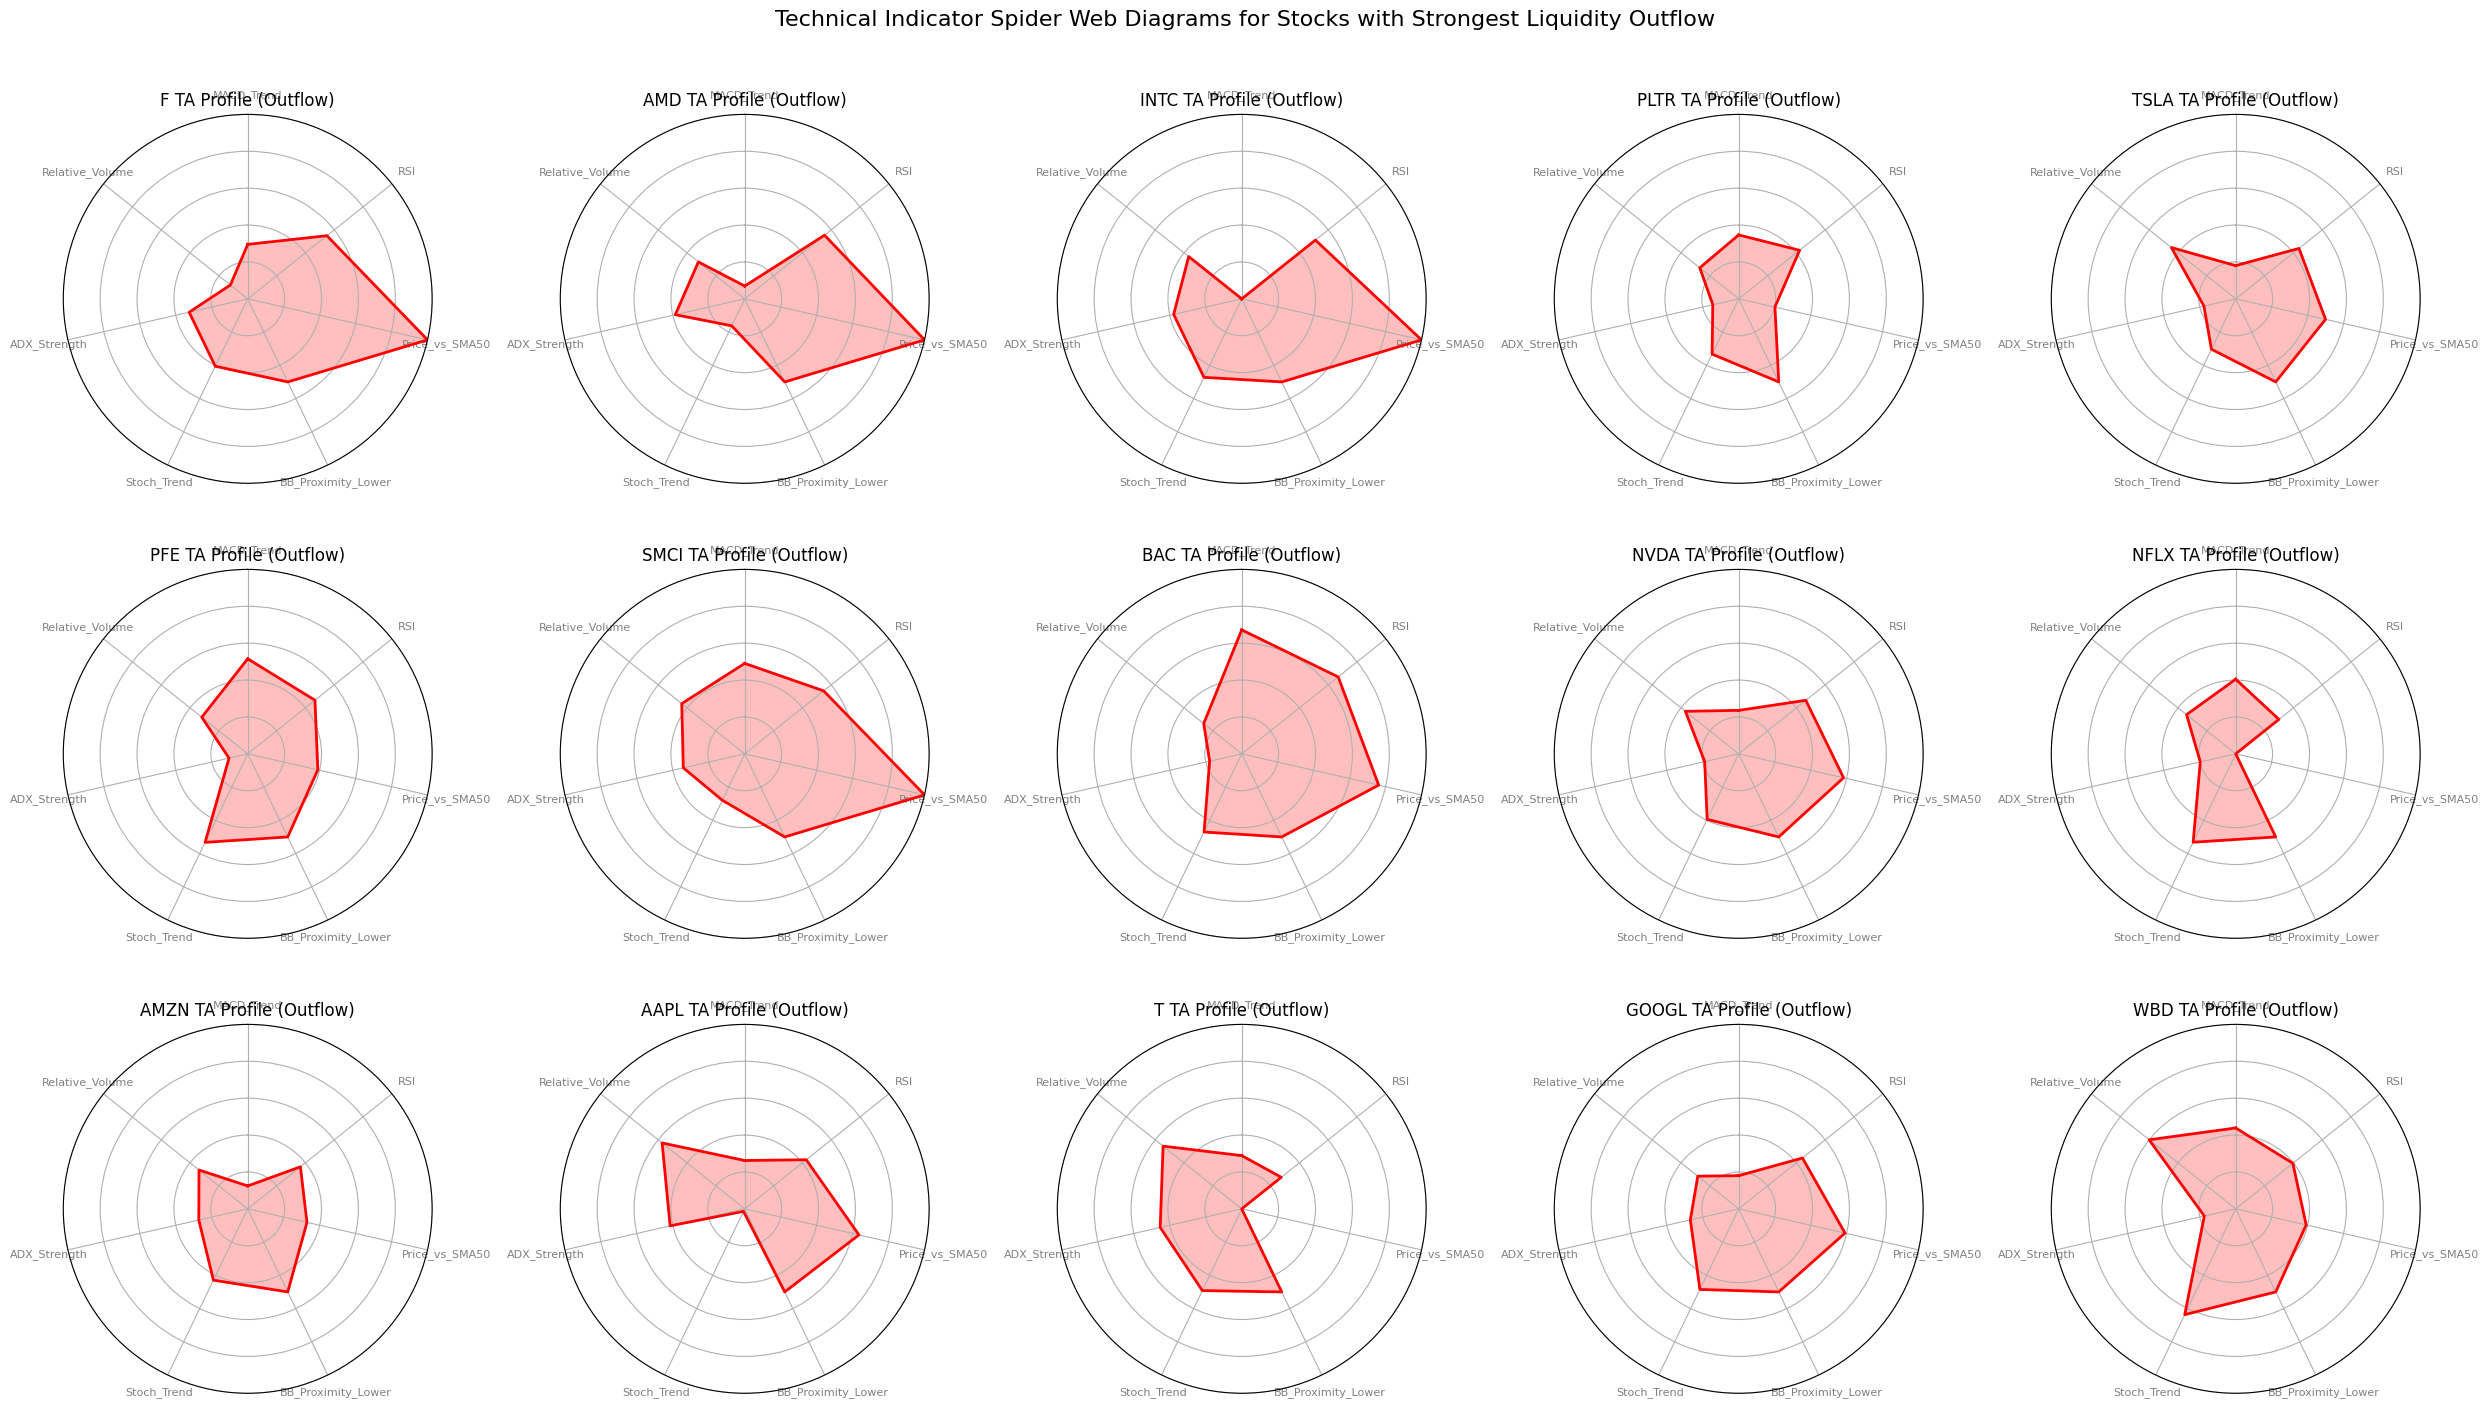

In [ ]:
from math import pi
import matplotlib.pyplot as plt

# Create a figure for all spider charts for liquidity outflow stocks
fig_outflow, axes_outflow = plt.subplots(nrows=3, ncols=5, figsize=(25, 15), subplot_kw=dict(polar=True))
axes_outflow = axes_outflow.flatten() # Flatten the 2D array of axes for easy iteration

# Ensure liquidity_outflow is a DataFrame (it was in the kernel state)
if 'liquidity_outflow' in locals() and not liquidity_outflow.empty:
    for i, (index, row) in enumerate(liquidity_outflow.iterrows()):
        if i >= len(axes_outflow): # Stop if we run out of subplots
            break

        symbol = row['Symbol']

        if symbol in all_stocks_data:
            df_stock = all_stocks_data[symbol].copy() # Get the raw data for the stock
            df_stock = standardize_yfinance_df_columns(df_stock) # Standardize columns
            normalized_indicators = get_normalized_indicators(df_stock, symbol)

            if normalized_indicators is not None:
                categories = list(normalized_indicators.keys())
                values = list(normalized_indicators.values())

                # Ensure the plot closes the circle
                categories = categories + [categories[0]]
                values = values + [values[0]]

                # Calculate angle for each category
                angles = [n / float(len(categories) - 1) * 2 * pi for n in range(len(categories))]

                # Plotting
                ax = axes_outflow[i]
                ax.set_theta_offset(pi / 2)
                ax.set_theta_direction(-1)

                # Draw one axe per variable + add labels labels yet
                ax.set_xticks(angles[:-1])
                ax.set_xticklabels(categories[:-1], color='grey', size=8)

                # Draw ylabels
                ax.set_yticklabels([]) # Hide radial labels for cleaner look
                ax.set_ylim(0, 1)

                ax.plot(angles, values, linewidth=2, linestyle='solid', label=symbol, color='red') # Using 'red' for outflow charts
                ax.fill(angles, values, 'red', alpha=0.25)
                ax.set_title(f'{symbol} TA Profile (Outflow)', size=12, color='black', position=(0.5, 1.1))
            else:
                axes_outflow[i].set_title(f'{symbol} - No Data', size=12, color='red')
                axes_outflow[i].axis('off') # Turn off axis for empty plot
        else:
            axes_outflow[i].set_title(f'{symbol} - Data Missing', size=12, color='red')
            axes_outflow[i].axis('off') # Turn off axis for empty plot

    # Hide any unused subplots
    for j in range(i + 1, len(axes_outflow)):
        axes_outflow[j].axis('off')

    fig_outflow.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent overlap
    fig_outflow.suptitle('Technical Indicator Spider Web Diagrams for Stocks with Strongest Liquidity Outflow', size=16, y=0.98)
    plt.show()
else:
    print("No liquidity outflow data to display spider web diagrams.")

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Filter below_all_smas_df for 'Monitor' or 'Potential Buy' decisions
monitor_buy_mfi_df = below_all_smas_df[
    (below_all_smas_df['Decision'].str.contains('Monitor')) |
    (below_all_smas_df['Decision'].str.contains('Potential Buy'))
].copy()

if not monitor_buy_mfi_df.empty:
    # Sort by MFI_Value for better visualization
    monitor_buy_mfi_df = monitor_buy_mfi_df.sort_values(by='MFI_Value', ascending=False)

    plt.figure(figsize=(12, 7))
    plt.bar(monitor_buy_mfi_df['Symbol'], monitor_buy_mfi_df['MFI_Value'], color='skyblue')
    plt.axhline(y=20, color='red', linestyle='--', label='Oversold Threshold (20)')
    plt.axhline(y=80, color='green', linestyle='--', label='Overbought Threshold (80)')
    plt.xlabel('Stock Symbol')
    plt.ylabel('Money Flow Index (MFI)')
    plt.title('Money Flow Index (MFI) for Monitor/Potential Buy Stocks')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, 100) # MFI typically ranges from 0 to 100
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No stocks found with 'Monitor' or 'Potential Buy' decisions to visualize MFI.")